# **Investment Replica – Portfolio Replication Project**
### Machine Learning per il Fintech – Politecnico di Milano

---

## Obiettivo del progetto

Vogliamo replicare un **"Monster Index"** (portafoglio black-box) usando contratti **Futures liquidi**.

Il Monster Index è costruito come combinazione pesata di:
- **HFRX Global Hedge Fund Index** – 50%
- **MSCI World** – 25%
- **Bloomberg Global Aggregate Bond Index** – 25%

I **replicanti** sono 11 contratti Futures su equity, bond, commodities e valute.

## Approccio metodologico

| Sezione | Contenuto |
|---------|----------|
| 1–2 | Setup, caricamento dati |
| 3–5 | EDA, analisi statistica, correlazioni |
| 6 | Modelli lineari: OLS, Ridge, Lasso, ElasticNet |
| 7 | Confronto modelli |
| 8 | Analisi approfondita del modello ottimale |
| **9** | **Kalman Filter (pesi dinamici adattativi)** |
| **10** | **Analisi per periodi di crisi (2008, 2011, 2020, 2022)** |
| **11** | **Replication Score composito** |
| 12 | Insight aggiuntivi (PCA, regime, costi) |
| 13 | Conclusioni |

MOLTISSIMI DATI-GRAFICI-RISULTATI. DEVO STUDIARLI ED ANALIZZARLI

---
## 1. Setup e caricamento librerie

In [ ]:
%pip install statsmodels openpyxl --quiet

In [1]:
# ============================================================
# IMPORT DELLE LIBRERIE
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Stile grafici uniforme per tutto il notebook
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.3)
plt.rcParams['figure.dpi'] = 100

print("Setup completato.")

Setup completato.


---
## 2. Caricamento e preprocessing del dataset

Il file Excel ha la riga 0 come intestazione (ticker), dalla riga 1 in poi ci sono i dati settimanali (Ott 2007 – Apr 2021).

In [2]:
# ============================================================
# CARICAMENTO DEL FILE EXCEL
# ============================================================

file_path = 'Dataset3_PortfolioReplicaStrategy.xlsx'  # <-- modifica se necessario

# header=0: prima riga come intestazione colonne
# index_col=0: prima colonna (date) come indice
data = pd.read_excel(file_path, header=0, index_col=0)
data.index = pd.to_datetime(data.index)
data.index.name = 'Date'

# Dizionario descrittivo: ticker → nome esteso
variable_info = {
    'MXWO'    : 'MSCI World (Developed Equities)',
    'MXWD'    : 'MSCI World All Country (ACWI)',
    'LEGATRUU': 'Bloomberg Global Aggregate Bond',
    'HFRXGL'  : 'HFRX Global Hedge Fund Index',
    'RX1'     : 'Bund Future 10Y (Germania)',
    'TY1'     : 'Treasury Future 10Y (USA)',
    'GC1'     : 'Gold Future',
    'CO1'     : 'Brent Crude Oil Future',
    'ES1'     : 'S&P 500 Future',
    'VG1'     : 'Eurostoxx 50 Future',
    'NQ1'     : 'Nasdaq 100 Future',
    'LLL1'    : 'MSCI Emerging Markets Future',
    'TP1'     : 'Topix Future (Giappone)',
    'DU1'     : 'Schatz Future 2Y (Germania)',
    'TU2'     : 'Treasury Future 2Y (USA)',
}

print(f"Dimensioni dataset: {data.shape[0]} righe x {data.shape[1]} colonne")
print(f"Periodo: {data.index[0].date()} → {data.index[-1].date()}")
print(f"Colonne: {data.columns.tolist()}")
display(data.head())

Dimensioni dataset: 705 righe x 15 colonne
Periodo: 2007-10-23 → 2021-04-20
Colonne: ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL', 'RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


In [3]:
# ============================================================
# DEFINIZIONE DEGLI STRUMENTI E CALCOLO RENDIMENTI
# ============================================================

# Indici: componenti del Monster Index + MXWD come riferimento
target_indices    = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']

# Futures: i replicanti liquidi (solo questi vengono usati nei modelli)
futures_contracts = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

# Rendimenti percentuali settimanali (log-return sarebbe equivalente per piccoli valori)
returns = data.pct_change().dropna()

index_returns   = returns[target_indices]
futures_returns = returns[futures_contracts]

# Fattore di annualizzazione per dati settimanali
annual_factor = 52

print(f"Rendimenti calcolati: {len(returns)} osservazioni settimanali")
print(f"Indici target : {target_indices}")
print(f"Futures       : {futures_contracts}")

Rendimenti calcolati: 704 osservazioni settimanali
Indici target : ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
Futures       : ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']


---
## 3. Esplorazione statistica degli indici

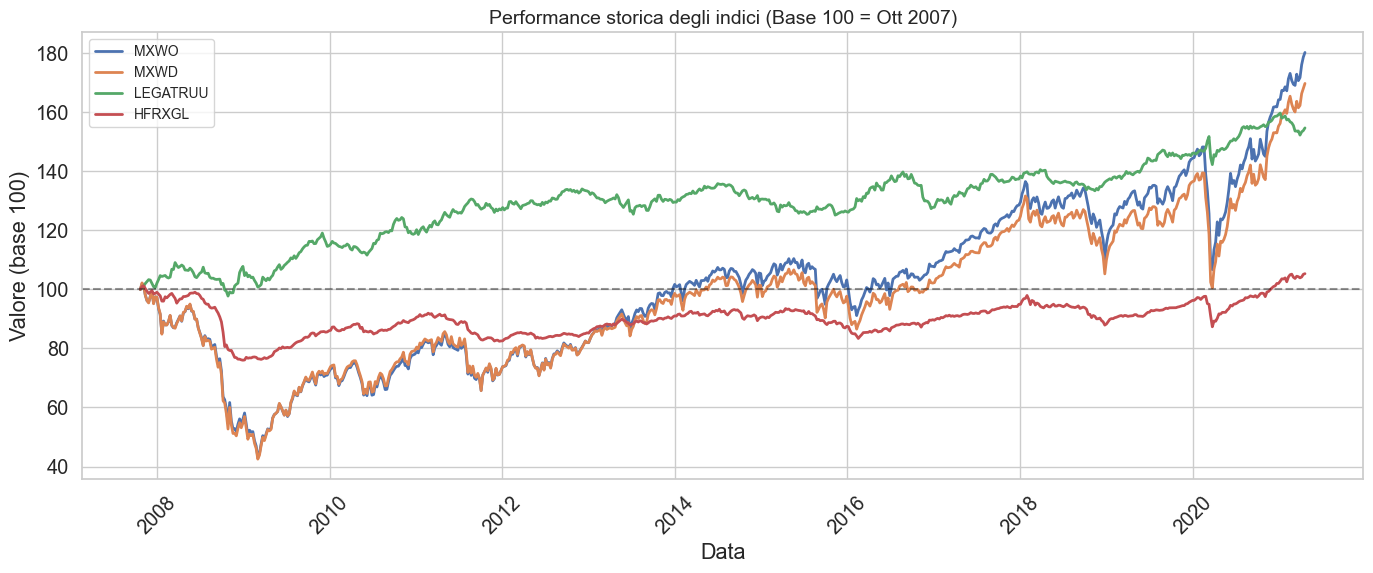

In [4]:
# ============================================================
# PERFORMANCE STORICA (normalizzata a 100)
# ============================================================
plt.figure(figsize=(14, 6))
for idx in target_indices:
    normalized = data[idx] / data[idx].iloc[0] * 100
    plt.plot(normalized.index, normalized, linewidth=2, label=idx)

plt.title('Performance storica degli indici (Base 100 = Ott 2007)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Valore (base 100)')
plt.legend(loc='upper left', fontsize=10)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# STATISTICHE DESCRITTIVE ANNUALIZZATE
# ============================================================
def calcola_statistiche(returns_df, label=''):
    """Calcola le statistiche annualizzate principali per ogni colonna."""
    stats_dict = {}
    for col in returns_df.columns:
        r = returns_df[col].dropna()
        ann_ret  = r.mean() * annual_factor
        ann_vol  = r.std() * np.sqrt(annual_factor)
        sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
        cum      = (1 + r).cumprod()
        drawdown = (1 - cum / cum.cummax()).max()
        stats_dict[col] = {
            'Return (ann.)'     : f"{ann_ret*100:.2f}%",
            'Volatility (ann.)' : f"{ann_vol*100:.2f}%",
            'Sharpe Ratio'      : f"{sharpe:.2f}",
            'Max Drawdown'      : f"{drawdown*100:.2f}%",
            'Skewness'          : f"{r.skew():.2f}",
            'Kurtosis (excess)' : f"{r.kurtosis():.2f}"
        }
    df = pd.DataFrame(stats_dict).T
    if label:
        print(f"\n--- {label} ---")
    return df

display(calcola_statistiche(index_returns, 'Indici target'))


--- Indici target ---


,Return (ann.),Volatility (ann.),Sharpe Ratio,Max Drawdown,Skewness,Kurtosis (excess)
MXWO,5.90%,17.52%,0.34,57.61%,-0.68,4.36
MXWD,5.51%,17.78%,0.31,58.39%,-0.64,4.66
LEGATRUU,3.37%,5.34%,0.63,10.41%,-0.33,4.12
HFRXGL,0.50%,4.78%,0.10,24.91%,-2.30,13.70


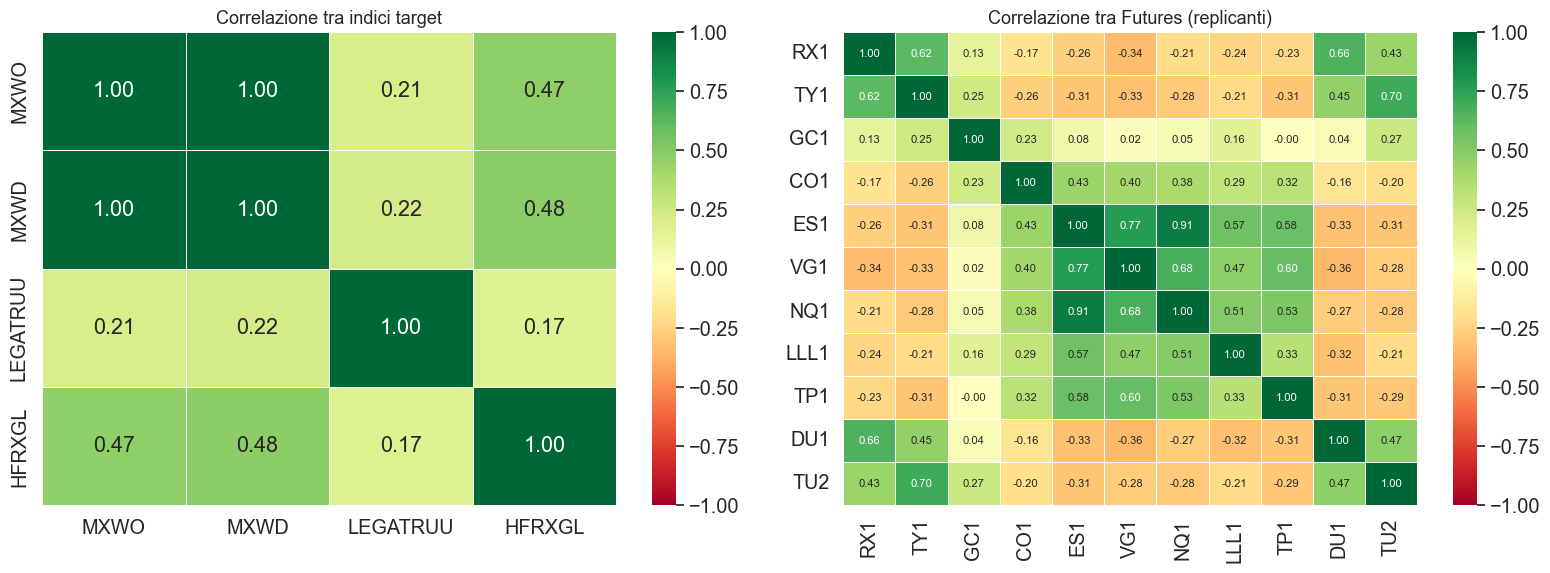

In [6]:
# ============================================================
# MATRICI DI CORRELAZIONE
# Alta correlazione tra Futures → multicollinearità
# → giustifica Ridge/Lasso rispetto all'OLS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(index_returns.corr(), annot=True, cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.2f', ax=axes[0])
axes[0].set_title('Correlazione tra indici target', fontsize=13)

sns.heatmap(futures_returns.corr(), annot=True, cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.2f', ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Correlazione tra Futures (replicanti)', fontsize=13)

plt.tight_layout()
plt.show()

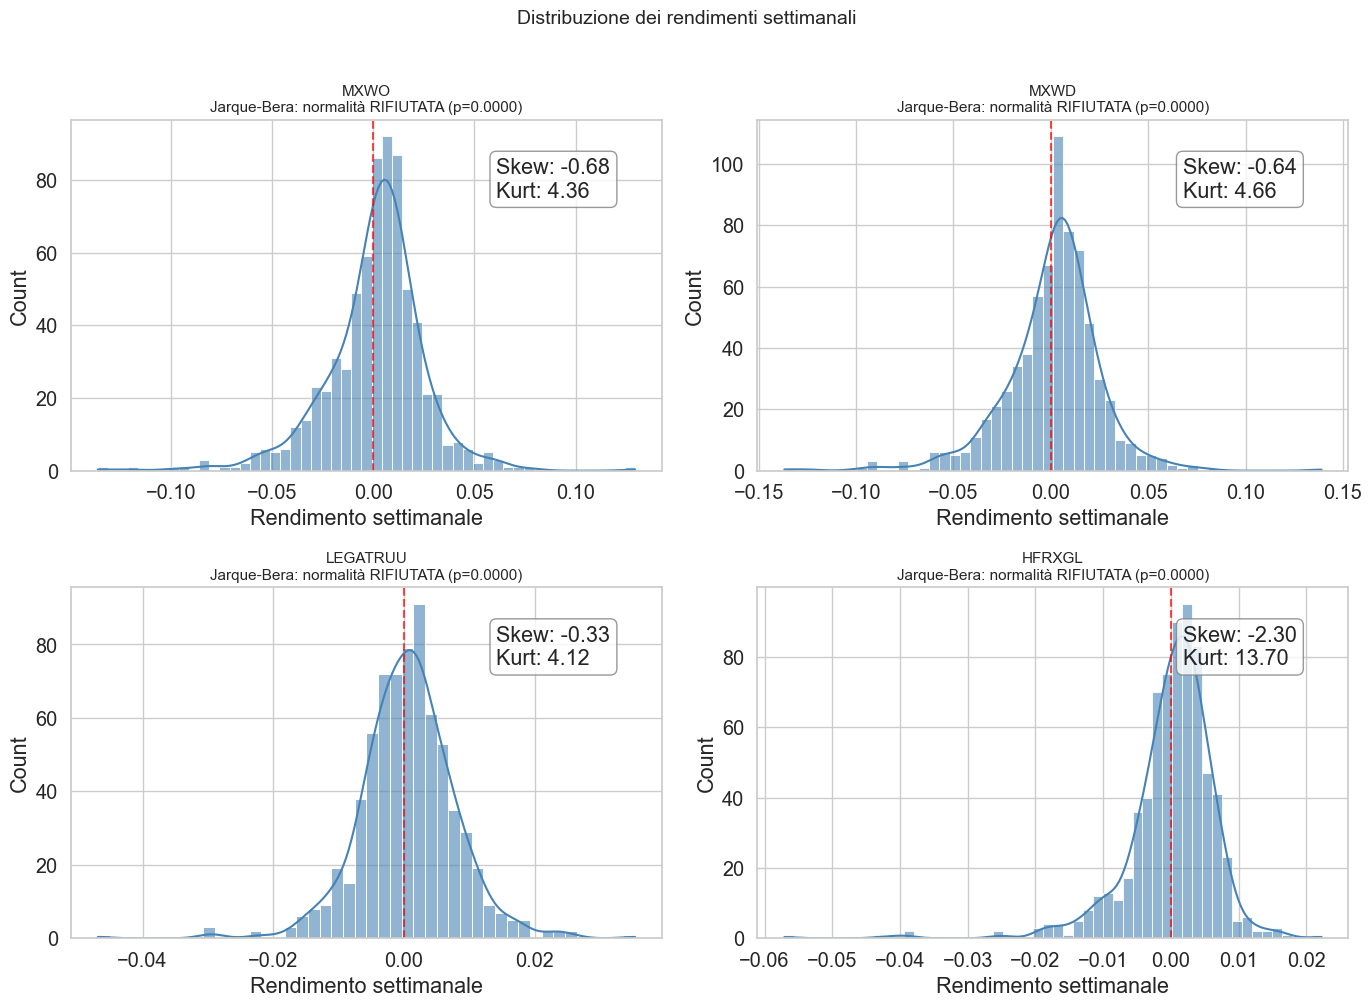

In [7]:
# ============================================================
# DISTRIBUZIONE DEI RENDIMENTI E TEST DI NORMALITÀ (Jarque-Bera)
# Fat tails → il VaR gaussiano sottostima il rischio reale
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(target_indices):
    r = index_returns[idx].dropna()
    sns.histplot(r, kde=True, ax=axes[i], color='steelblue', alpha=0.6)
    axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    jb_stat, jb_pval = stats.jarque_bera(r)
    normal_test = "RIFIUTATA" if jb_pval < 0.05 else "non rifiutata"
    axes[i].set_title(f'{idx}\nJarque-Bera: normalità {normal_test} (p={jb_pval:.4f})', fontsize=11)
    axes[i].set_xlabel('Rendimento settimanale')
    axes[i].annotate(
        f'Skew: {r.skew():.2f}\nKurt: {r.kurtosis():.2f}',
        xy=(0.72, 0.78), xycoords='axes fraction',
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8)
    )

plt.suptitle('Distribuzione dei rendimenti settimanali', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

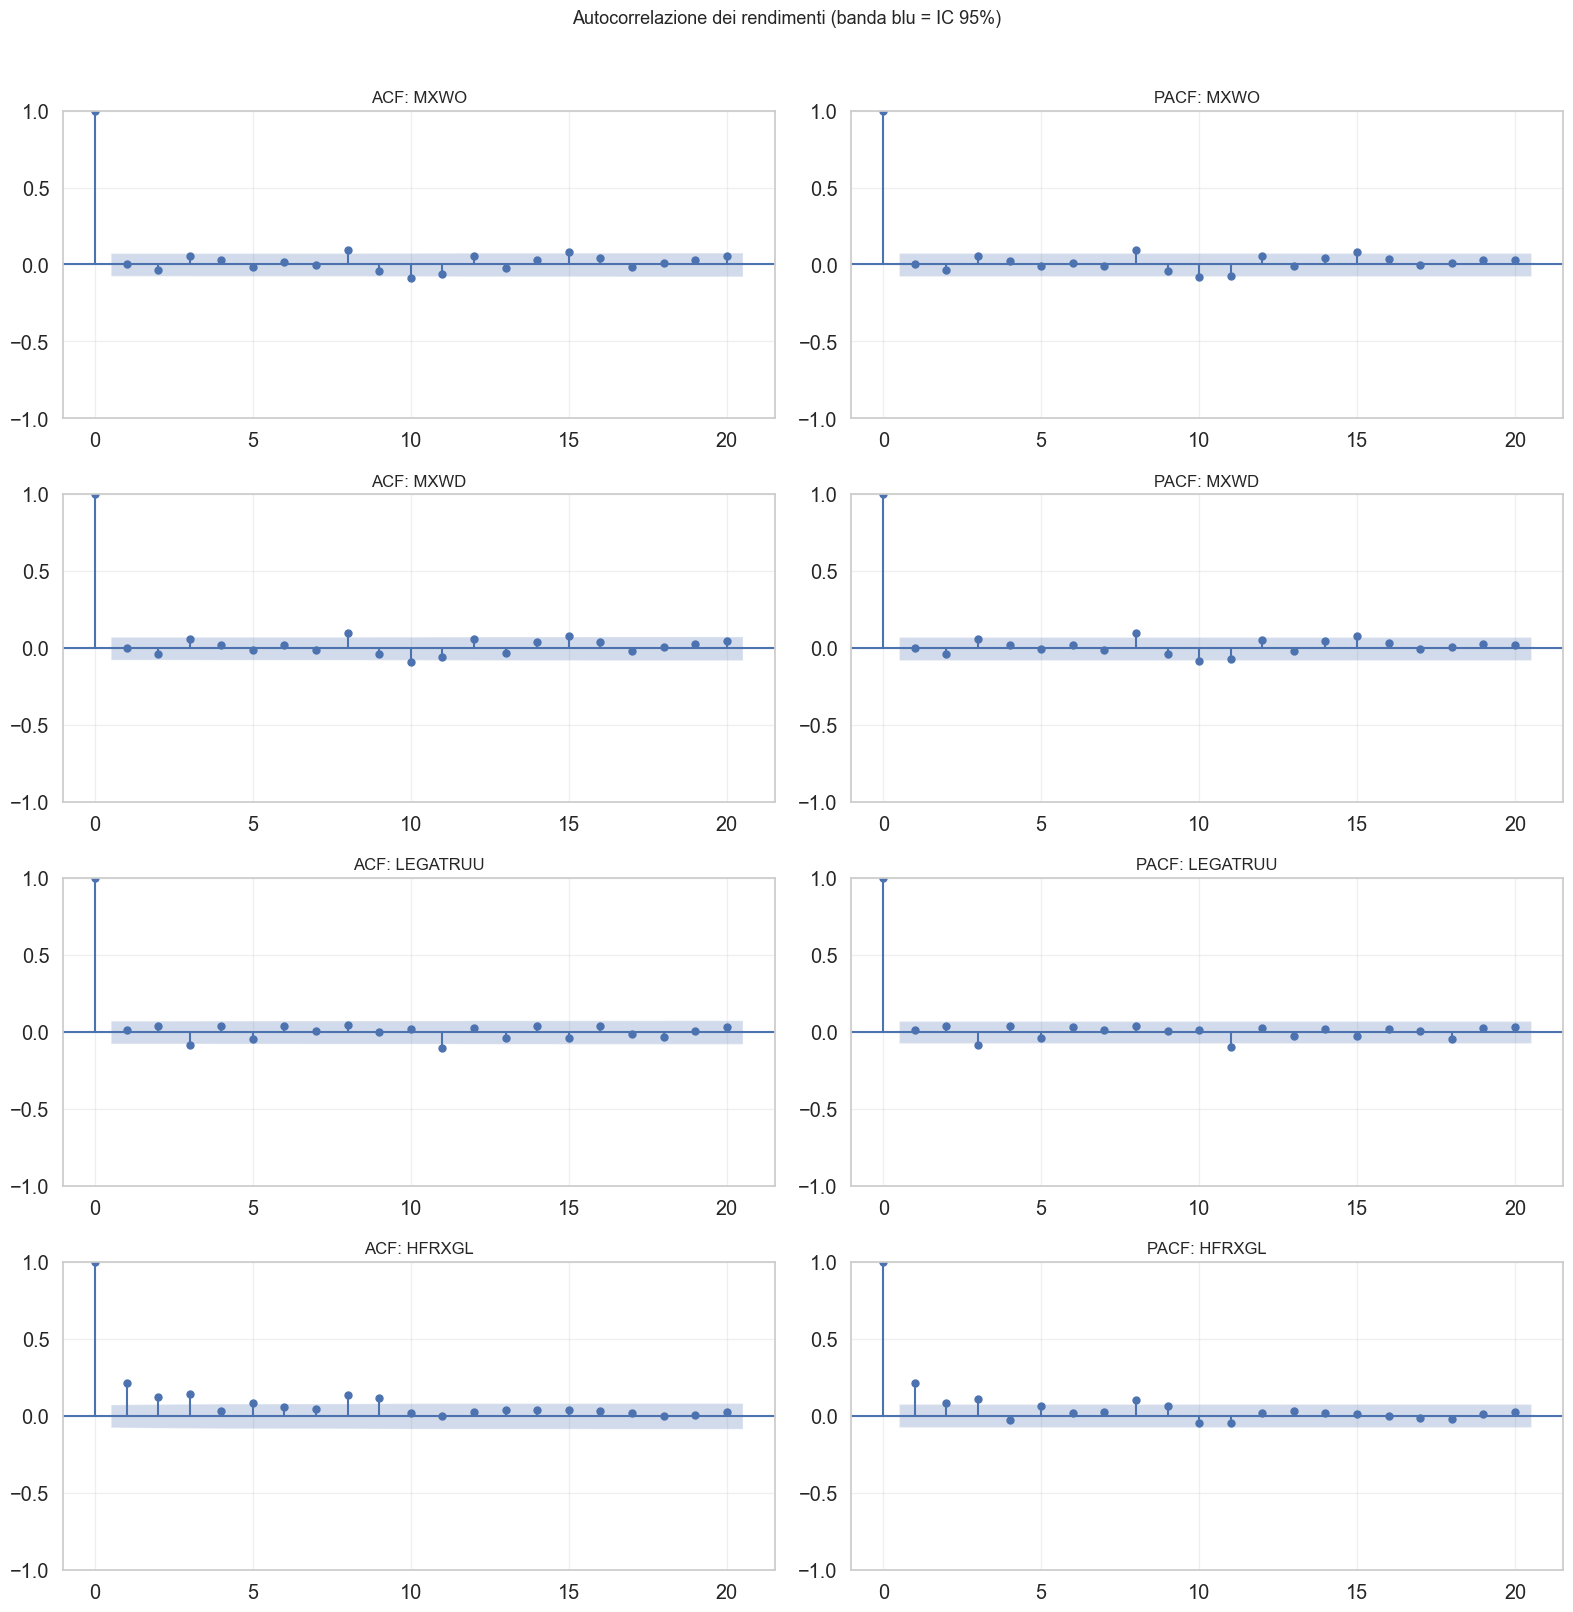

Test Ljung-Box (H0: nessuna autocorrelazione)

  MXWO:
    Lag  5: p=0.5905 → nessuna autocorr.
    Lag 10: p=0.0910 → nessuna autocorr.
    Lag 20: p=0.0521 → nessuna autocorr.

  MXWD:
    Lag  5: p=0.5393 → nessuna autocorr.
    Lag 10: p=0.0653 → nessuna autocorr.
    Lag 20: p=0.0432 → autocorr. presente

  LEGATRUU:
    Lag  5: p=0.1364 → nessuna autocorr.
    Lag 10: p=0.3071 → nessuna autocorr.
    Lag 20: p=0.1484 → nessuna autocorr.

  HFRXGL:
    Lag  5: p=0.0000 → autocorr. presente
    Lag 10: p=0.0000 → autocorr. presente
    Lag 20: p=0.0000 → autocorr. presente



In [8]:
# ============================================================
# AUTOCORRELAZIONE (ACF/PACF) E TEST LJUNG-BOX
# ============================================================
max_lags = 20
fig, axes = plt.subplots(len(target_indices), 2, figsize=(16, 4*len(target_indices)))

for i, idx in enumerate(target_indices):
    r = index_returns[idx].dropna()
    plot_acf(r,  lags=max_lags, ax=axes[i, 0], alpha=0.05)
    axes[i, 0].set_title(f'ACF: {idx}', fontsize=12)
    axes[i, 0].grid(True, alpha=0.3)
    plot_pacf(r, lags=max_lags, ax=axes[i, 1], alpha=0.05)
    axes[i, 1].set_title(f'PACF: {idx}', fontsize=12)
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Autocorrelazione dei rendimenti (banda blu = IC 95%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Test Ljung-Box (H0: nessuna autocorrelazione)\n")
for idx in target_indices:
    r = index_returns[idx].dropna()
    lb = acorr_ljungbox(r, lags=[5, 10, 20])
    print(f"  {idx}:")
    for lag, row in zip([5, 10, 20], lb.itertuples()):
        esito = "autocorr. presente" if row.lb_pvalue < 0.05 else "nessuna autocorr."
        print(f"    Lag {lag:2d}: p={row.lb_pvalue:.4f} → {esito}")
    print()

---
## 4. Costruzione del Monster Index (target)

In [9]:
# ============================================================
# COSTRUZIONE DEL MONSTER INDEX
# Combinazione lineare pesata dei tre indici componenti
# ============================================================
monster_weights = {
    'HFRXGL'  : 0.50,   # 50% Hedge Fund Index
    'MXWO'    : 0.25,   # 25% MSCI World equity
    'LEGATRUU': 0.25,   # 25% Bloomberg Aggregate Bond
}

component_returns = returns[list(monster_weights.keys())]
target_returns    = sum(component_returns[col] * w for col, w in monster_weights.items())
target_returns.name = 'Monster_Index'

# Allineamento date: usiamo solo le settimane in cui tutti i dati sono disponibili
futures_ret    = futures_returns.copy()
common_dates   = futures_ret.index.intersection(target_returns.index)
futures_ret    = futures_ret.loc[common_dates]
target_aligned = target_returns.loc[common_dates]

# Statistiche del target
ann_ret = target_aligned.mean() * annual_factor
ann_vol = target_aligned.std()  * np.sqrt(annual_factor)
cum_tgt = (1 + target_aligned).cumprod()
mdd_tgt = (1 - cum_tgt / cum_tgt.cummax()).max()

print(f"Monster Index – {len(target_aligned)} osservazioni")
print(f"  Return ann.   : {ann_ret*100:.2f}%")
print(f"  Volatilità    : {ann_vol*100:.2f}%")
print(f"  Sharpe Ratio  : {ann_ret/ann_vol:.2f}")
print(f"  Max Drawdown  : {mdd_tgt*100:.2f}%")

Monster Index – 704 osservazioni
  Return ann.   : 2.57%
  Volatilità    : 6.33%
  Sharpe Ratio  : 0.41
  Max Drawdown  : 29.01%


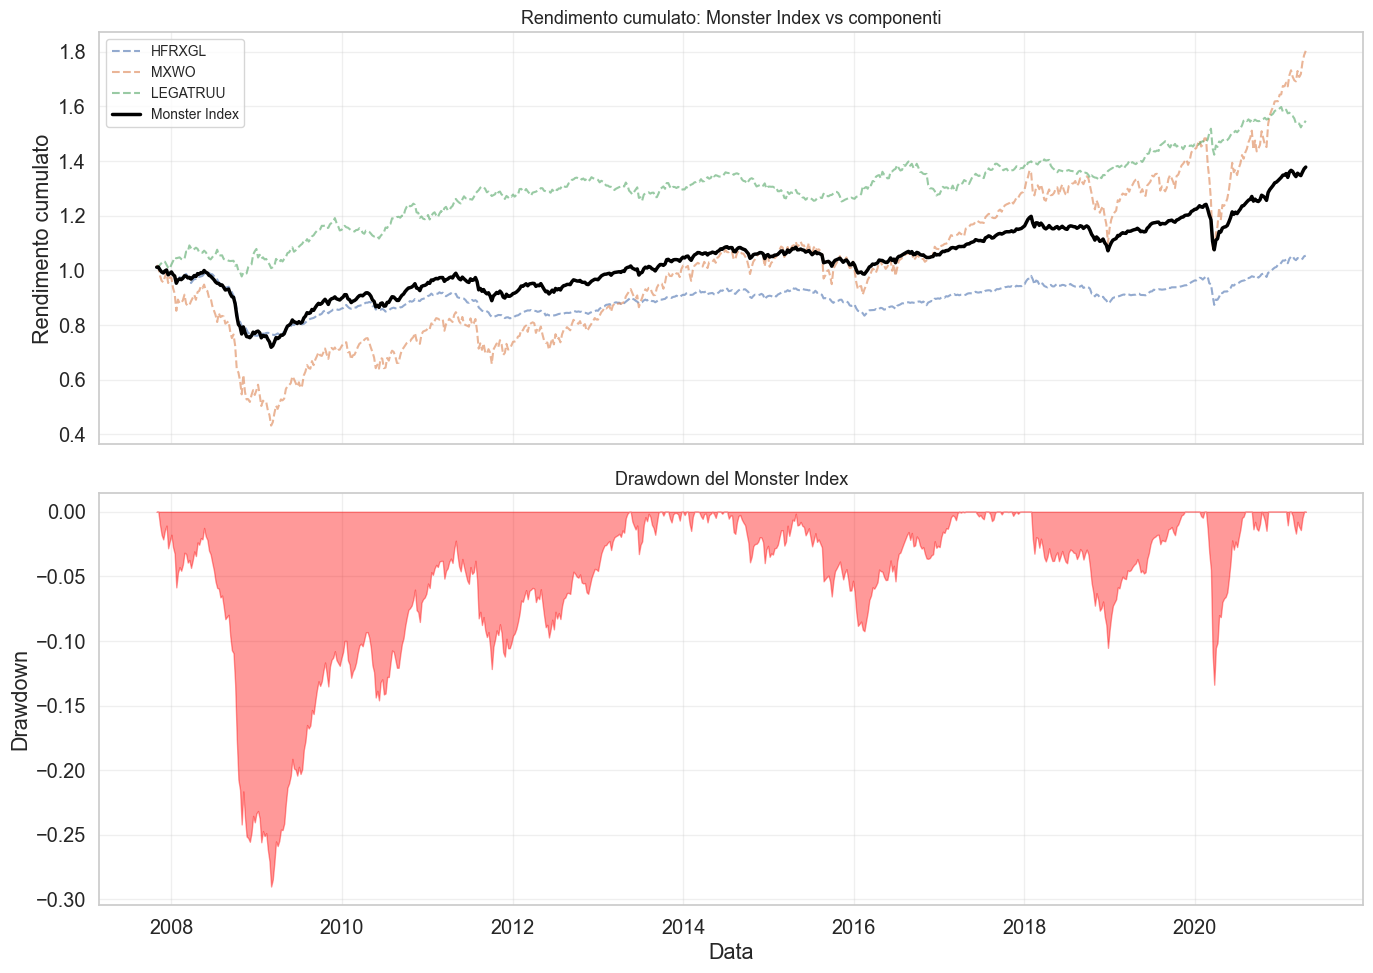

In [10]:
# ============================================================
# GRAFICO: Monster Index vs componenti
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

cum_monster = (1 + target_aligned).cumprod()
for col in monster_weights:
    cum_comp = (1 + returns[col].loc[common_dates]).cumprod()
    axes[0].plot(cum_comp, alpha=0.6, linewidth=1.5, linestyle='--', label=col)
axes[0].plot(cum_monster, color='black', linewidth=2.5, label='Monster Index')
axes[0].set_title('Rendimento cumulato: Monster Index vs componenti', fontsize=13)
axes[0].set_ylabel('Rendimento cumulato')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

drawdown = 1 - cum_monster / cum_monster.cummax()
axes[1].fill_between(drawdown.index, 0, -drawdown, color='red', alpha=0.4)
axes[1].set_title('Drawdown del Monster Index', fontsize=13)
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Data')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Correlazione tra Monster Index e Futures

,Correlazione con Monster Index
ES1,0.837925
NQ1,0.746908
VG1,0.730608
TP1,0.598764
LLL1,0.498685
CO1,0.444804
DU1,-0.261666
GC1,0.218268
TU2,-0.152824
RX1,-0.130681


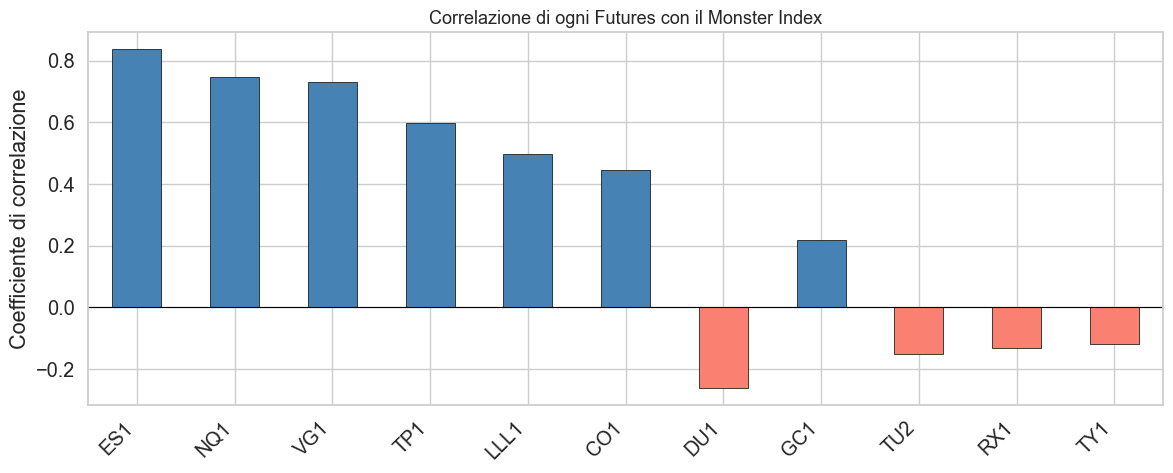

In [11]:
# ============================================================
# CORRELAZIONE STATICA: Monster Index vs ogni Futures
# ============================================================
corr_with_target = (
    futures_ret
    .apply(lambda col: target_aligned.corr(col))
    .rename('Correlazione con Monster Index')
    .sort_values(key=abs, ascending=False)
)
display(corr_with_target.to_frame())

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue' if v >= 0 else 'salmon' for v in corr_with_target]
corr_with_target.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Correlazione di ogni Futures con il Monster Index', fontsize=13)
ax.set_ylabel('Coefficiente di correlazione')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

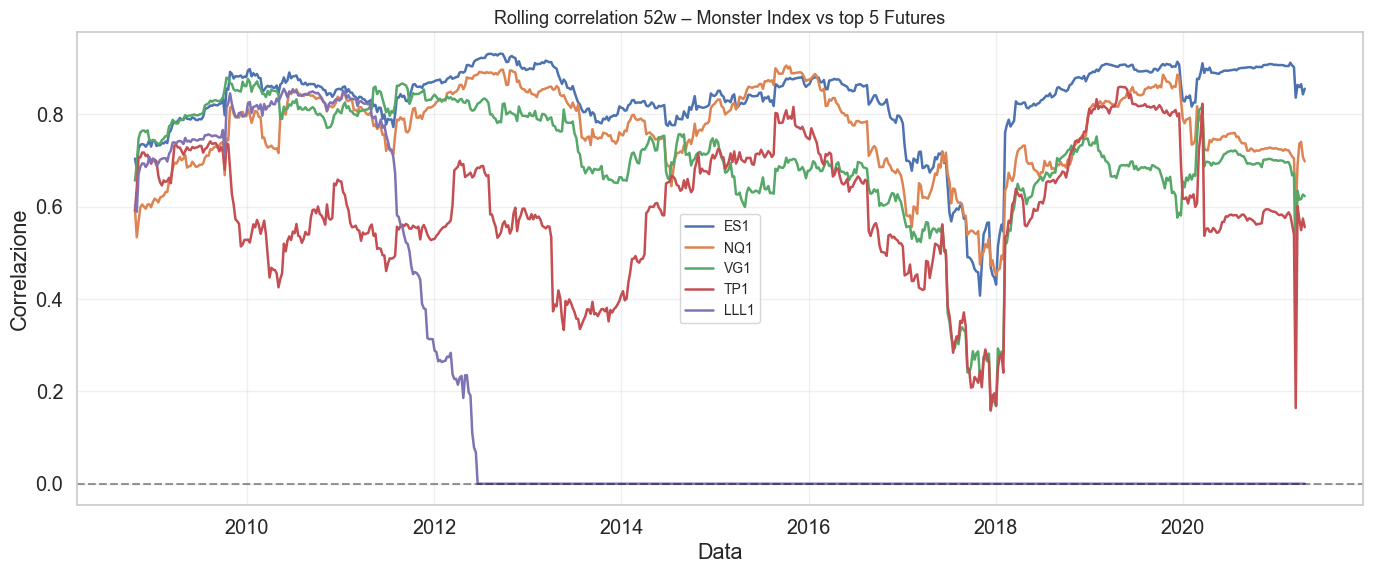

→ La correlazione varia nel tempo: giustifica il rolling window nel backtest.


In [12]:
# ============================================================
# ROLLING CORRELATION (52w) – instabilità temporale
# Motivazione per il rolling window nel backtest
# ============================================================
top5_futures = corr_with_target.index[:5].tolist()

plt.figure(figsize=(14, 6))
for contract in top5_futures:
    df_tmp = pd.DataFrame({'Target': target_aligned, 'Future': futures_ret[contract]})
    rc = df_tmp['Target'].rolling(52).corr(df_tmp['Future'])
    plt.plot(rc.index, rc, linewidth=1.8, label=contract)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.4)
plt.title('Rolling correlation 52w – Monster Index vs top 5 Futures', fontsize=13)
plt.xlabel('Data')
plt.ylabel('Correlazione')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ La correlazione varia nel tempo: giustifica il rolling window nel backtest.")

---
## 6. Modelli di regressione lineare

### Perché un modello lineare?

Un portafoglio è per definizione una **combinazione lineare** di asset:
$$r_p = \sum_j w_j \cdot r_j$$
I coefficienti $\beta_j$ della regressione mappano direttamente sui **pesi del portafoglio replicante**.

| Modello | Penalità | Proprietà principale |
|---------|----------|-----------------------|
| OLS | — | Baseline, max R² in-sample |
| Ridge | $\lambda\sum\beta_j^2$ | Gestisce multicollinearità, tutti i pesi non zero |
| Lasso | $\lambda\sum|\beta_j|$ | Sparse: azzera i pesi irrilevanti, selezione features |
| Elastic Net | mix L1+L2 | Compromesso: sparse ma stabile con features correlate |

In [13]:
# ============================================================
# FUNZIONI DI SUPPORTO CONDIVISE DA TUTTI I MODELLI
# ============================================================

def calcola_var_gaussiana(rendimenti, confidence=0.01, horizon=4):
    """
    Value-at-Risk con modello Gaussiano.
    confidence : livello (default 1% → VaR 99%)
    horizon    : settimane (default 4 = 1 mese)
    Ritorna: VaR come numero positivo (perdita attesa).
    """
    sigma = np.std(rendimenti)
    z     = stats.norm.ppf(confidence)     # es. -2.33 per confidence=1%
    return -z * sigma * np.sqrt(horizon)


def calcola_metriche(replica_series, target_series, annual_factor=52):
    """
    Metriche di performance out-of-sample tra replica e target.
    Tutte le metriche annualizzate dove applicabile.
    """
    r_rep = replica_series
    r_tgt = target_series

    ann_ret_rep  = r_rep.mean() * annual_factor
    ann_ret_tgt  = r_tgt.mean() * annual_factor
    ann_vol_rep  = r_rep.std()  * np.sqrt(annual_factor)
    ann_vol_tgt  = r_tgt.std()  * np.sqrt(annual_factor)
    sharpe_rep   = ann_ret_rep / ann_vol_rep if ann_vol_rep > 0 else np.nan
    sharpe_tgt   = ann_ret_tgt / ann_vol_tgt if ann_vol_tgt > 0 else np.nan

    diff         = r_rep - r_tgt
    tracking_err = diff.std() * np.sqrt(annual_factor)
    info_ratio   = (ann_ret_rep - ann_ret_tgt) / tracking_err if tracking_err > 0 else np.nan
    correlation  = r_rep.corr(r_tgt)

    cum_rep      = (1 + r_rep).cumprod()
    cum_tgt_loc  = (1 + r_tgt).cumprod()
    max_dd_rep   = (1 - cum_rep / cum_rep.cummax()).max()
    max_dd_tgt   = (1 - cum_tgt_loc / cum_tgt_loc.cummax()).max()
    # Drawdown relativo: quanto più alto è il drawdown della replica rispetto al target
    mdd_rel      = max_dd_rep / max_dd_tgt if max_dd_tgt > 0 else np.nan

    return {
        'ann_return'     : ann_ret_rep,
        'ann_vol'        : ann_vol_rep,
        'sharpe'         : sharpe_rep,
        'max_drawdown'   : max_dd_rep,
        'mdd_rel'        : mdd_rel,       # usato nel Replication Score
        'tracking_error' : tracking_err,
        'info_ratio'     : info_ratio,
        'correlation'    : correlation,
        'tgt_return'     : ann_ret_tgt,
        'tgt_vol'        : ann_vol_tgt,
        'tgt_sharpe'     : sharpe_tgt,
        'tgt_max_dd'     : max_dd_tgt,
    }


print("Funzioni di supporto definite.")

Funzioni di supporto definite.


In [14]:
# ============================================================
# BACKTEST ROLLING WINDOW
# Addestra il modello su una finestra mobile di K settimane,
# predice il rendimento della settimana successiva (OOS),
# poi avanza di una settimana e ripete.
# ============================================================

VAR_CONFIDENCE = 0.01   # VaR al 99%
VAR_HORIZON    = 4      # 1 mese (4 settimane)
VAR_MAX        = 0.08   # 8% – limite prudente (UCITS: max VaR 20%)


def backtest_rolling(
    model,
    X_vals, y_vals, dates,
    rolling_window=52,
    normalizza=True,
    costo_transazione=0.0005   # 5 bps per unità di turnover
):
    """
    Backtest rolling window per qualsiasi modello sklearn con .fit() e .coef_.

    Parametri
    ---------
    model              : istanza sklearn già configurata
    X_vals             : numpy array (T x N_futures) rendimenti Futures
    y_vals             : numpy array (T,) rendimenti target
    dates              : array di date corrispondenti
    rolling_window     : settimane nella finestra di training
    normalizza         : se True applica MinMaxScaler (necessario per Ridge/Lasso/EN)
    costo_transazione  : frazione applicata a ogni unità di turnover

    Ritorna
    -------
    Dizionario con metriche scalari + serie temporali (replica, target, pesi, ...)
    """
    n           = len(X_vals)
    replica_ret = []
    rep_dates   = []
    pesi_hist   = []
    gross_exp   = []
    var_hist    = []
    turnover_h  = []
    pesi_prev   = np.zeros(X_vals.shape[1])

    for t in range(n - rolling_window - 1):
        X_train = X_vals[t : t + rolling_window]
        y_train = y_vals[t : t + rolling_window]

        if normalizza:
            sx = MinMaxScaler()
            X_train_n = sx.fit_transform(X_train)
            sy = MinMaxScaler()
            y_train_n = sy.fit_transform(y_train.reshape(-1, 1)).ravel()
        else:
            X_train_n, y_train_n = X_train, y_train

        model.fit(X_train_n, y_train_n)
        pesi_norm = model.coef_

        # Riscalamento pesi nello spazio originale (annulla la normalizzazione)
        pesi = pesi_norm / sx.scale_ if normalizza else pesi_norm

        # --- Vincolo VaR regolatorio (UCITS) ---
        if len(replica_ret) >= 12:
            storico = np.array(replica_ret[-min(52, len(replica_ret)):])
            var_est = calcola_var_gaussiana(storico, VAR_CONFIDENCE, VAR_HORIZON)
            if var_est > VAR_MAX:
                pesi   *= VAR_MAX / var_est   # scaling proporzionale
                var_est = VAR_MAX
            var_hist.append(var_est)
        else:
            var_hist.append(np.nan)

        # --- Costo di transazione proporzionale al turnover ---
        turnover = np.sum(np.abs(pesi - pesi_prev))
        turnover_h.append(turnover)

        x_next     = X_vals[t + rolling_window]
        ret_netto  = np.dot(x_next, pesi) - costo_transazione * turnover

        replica_ret.append(ret_netto)
        rep_dates.append(dates[t + rolling_window])
        pesi_hist.append(pesi.copy())
        gross_exp.append(np.sum(np.abs(pesi)))
        pesi_prev = pesi.copy()

    replica_series = pd.Series(replica_ret, index=rep_dates)
    target_series  = target_aligned.loc[replica_series.index]
    metriche       = calcola_metriche(replica_series, target_series)
    avg_turnover   = np.mean(turnover_h)

    return {
        **metriche,
        'avg_turnover'     : avg_turnover,
        'replica_returns'  : replica_series,
        'target_returns'   : target_series,
        'pesi_history'     : pd.DataFrame(pesi_hist, index=rep_dates, columns=futures_contracts),
        'gross_exposure'   : pd.Series(gross_exp, index=rep_dates),
        'var_history'      : pd.Series(var_hist, index=rep_dates),
        'turnover_history' : pd.Series(turnover_h, index=rep_dates),
    }


# Dati in formato numpy per il backtest
X_vals = futures_ret.values
y_vals = target_aligned.values
dates  = futures_ret.index.to_numpy()

print(f"Dati preparati: X={X_vals.shape}, y={y_vals.shape}")
print("Funzione backtest_rolling definita.")

Dati preparati: X=(704, 11), y=(704,)
Funzione backtest_rolling definita.


### 6.1 OLS – Baseline

In [15]:
print("Eseguendo backtest OLS (baseline)...")
ols_result = backtest_rolling(
    LinearRegression(fit_intercept=False),
    X_vals, y_vals, dates,
    rolling_window=52, normalizza=False   # OLS non richiede normalizzazione
)
print(f"OLS → corr={ols_result['correlation']:.4f}, TE={ols_result['tracking_error']*100:.2f}%, IR={ols_result['info_ratio']:.3f}")

Eseguendo backtest OLS (baseline)...
OLS → corr=0.8562, TE=3.18%, IR=-0.413


### 6.2 Ridge – Penalità L2 (grid search)

In [16]:
ridge_alphas    = [0.0001, 0.001, 0.01, 0.1, 1.0]
rolling_windows = [52, 104]   # 1 anno, 2 anni

ridge_results = []
print("Grid search Ridge...")
for rw, alpha in product(rolling_windows, ridge_alphas):
    res = backtest_rolling(Ridge(alpha=alpha, fit_intercept=False),
                           X_vals, y_vals, dates, rolling_window=rw)
    ridge_results.append({'model':'Ridge','rolling_window':rw,'alpha':alpha,
                          **{k:v for k,v in res.items() if not isinstance(v,(pd.Series,pd.DataFrame))}})

ridge_df = pd.DataFrame(ridge_results).sort_values('correlation', ascending=False)
print("\nTop 5 Ridge:")
display(ridge_df[['rolling_window','alpha','correlation','tracking_error','info_ratio','sharpe']].head(5).round(4))

Grid search Ridge...

Top 5 Ridge:


,rolling_window,alpha,correlation,tracking_error,info_ratio,sharpe
8,104,0.1000,0.7680,0.0385,-0.4897,0.6744
7,104,0.0100,0.7581,0.0388,-0.5124,0.6322
6,104,0.0010,0.7537,0.0389,-0.5134,0.6242
5,104,0.0001,0.7532,0.0389,-0.5135,0.6233
0,52,0.0001,0.7348,0.0425,-0.6242,0.5685


### 6.3 Lasso – Penalità L1 (sparse, grid search)

In [17]:
lasso_alphas = [0.0001, 0.001, 0.01, 0.1]

lasso_results = []
print("Grid search Lasso...")
for rw, alpha in product(rolling_windows, lasso_alphas):
    res = backtest_rolling(Lasso(alpha=alpha, fit_intercept=False, max_iter=10000),
                           X_vals, y_vals, dates, rolling_window=rw)
    lasso_results.append({'model':'Lasso','rolling_window':rw,'alpha':alpha,
                          **{k:v for k,v in res.items() if not isinstance(v,(pd.Series,pd.DataFrame))}})

lasso_df = pd.DataFrame(lasso_results).sort_values('correlation', ascending=False)
print("\nTop 5 Lasso:")
display(lasso_df[['rolling_window','alpha','correlation','tracking_error','info_ratio','sharpe']].head(5).round(4))

Grid search Lasso...

Top 5 Lasso:


,rolling_window,alpha,correlation,tracking_error,info_ratio,sharpe
5,104,0.0010,0.7889,0.0381,-0.5378,0.6483
6,104,0.0100,0.7813,0.0404,-0.5441,0.7048
4,104,0.0001,0.7714,0.0384,-0.5223,0.6352
2,52,0.0100,0.7702,0.0432,-0.7058,0.5521
1,52,0.0010,0.7536,0.0420,-0.6800,0.5287


### 6.4 Elastic Net – Mix L1+L2 (grid search)

In [18]:
en_alphas    = [0.0001, 0.001, 0.01]
en_l1_ratios = [0.2, 0.5, 0.8, 1.0]

en_results = []
print("Grid search Elastic Net...")
for rw, alpha, l1 in product(rolling_windows, en_alphas, en_l1_ratios):
    res = backtest_rolling(ElasticNet(alpha=alpha, l1_ratio=l1, fit_intercept=False, max_iter=10000),
                           X_vals, y_vals, dates, rolling_window=rw)
    en_results.append({'model':'ElasticNet','rolling_window':rw,'alpha':alpha,'l1_ratio':l1,
                       **{k:v for k,v in res.items() if not isinstance(v,(pd.Series,pd.DataFrame))}})

en_df = pd.DataFrame(en_results).sort_values('correlation', ascending=False)
print("\nTop 5 ElasticNet:")
display(en_df[['rolling_window','alpha','l1_ratio','correlation','tracking_error','info_ratio','sharpe']].head(5).round(4))

Grid search Elastic Net...

Top 5 ElasticNet:


,rolling_window,alpha,l1_ratio,correlation,tracking_error,info_ratio,sharpe
19,104,0.001,1.0,0.7889,0.0381,-0.5378,0.6483
18,104,0.001,0.8,0.7856,0.0382,-0.5292,0.6548
23,104,0.010,1.0,0.7813,0.0404,-0.5441,0.7048
17,104,0.001,0.5,0.7806,0.0383,-0.5173,0.6617
22,104,0.010,0.8,0.7774,0.0402,-0.5296,0.7134


---
## 7. Confronto tra modelli lineari

In [19]:
# ============================================================
# RIESECUZIONE DEI BEST PER OGNI MODELLO (con serie temporali complete)
# ============================================================
best_ridge = ridge_df.iloc[0]
best_lasso = lasso_df.iloc[0]
best_en    = en_df.iloc[0]

best_ridge_full = backtest_rolling(
    Ridge(alpha=best_ridge['alpha'], fit_intercept=False),
    X_vals, y_vals, dates, rolling_window=int(best_ridge['rolling_window']))

best_lasso_full = backtest_rolling(
    Lasso(alpha=best_lasso['alpha'], fit_intercept=False, max_iter=10000),
    X_vals, y_vals, dates, rolling_window=int(best_lasso['rolling_window']))

best_en_full = backtest_rolling(
    ElasticNet(alpha=best_en['alpha'], l1_ratio=best_en['l1_ratio'],
               fit_intercept=False, max_iter=10000),
    X_vals, y_vals, dates, rolling_window=int(best_en['rolling_window']))

# --- Tabella riepilogativa ---
confronto = pd.DataFrame([
    {'Modello': 'OLS',
     **calcola_metriche(ols_result['replica_returns'], ols_result['target_returns'])},
    {'Modello': f'Ridge (α={best_ridge["alpha"]})',
     **calcola_metriche(best_ridge_full['replica_returns'], best_ridge_full['target_returns'])},
    {'Modello': f'Lasso (α={best_lasso["alpha"]})',
     **calcola_metriche(best_lasso_full['replica_returns'], best_lasso_full['target_returns'])},
    {'Modello': f'ElasticNet (α={best_en["alpha"]}, l1={best_en["l1_ratio"]})',
     **calcola_metriche(best_en_full['replica_returns'], best_en_full['target_returns'])},
]).set_index('Modello')

fmt_pct = lambda x: f"{x*100:.2f}%"
fmt_num = lambda x: f"{x:.4f}"
disp_df = confronto[['correlation','tracking_error','info_ratio','ann_return','ann_vol','sharpe','max_drawdown']].copy()
for c in ['tracking_error','ann_return','ann_vol','max_drawdown']:
    disp_df[c] = disp_df[c].map(fmt_pct)
for c in ['correlation','info_ratio','sharpe']:
    disp_df[c] = disp_df[c].map(fmt_num)

print("CONFRONTO MODELLI LINEARI – Metriche out-of-sample:")
display(disp_df)

CONFRONTO MODELLI LINEARI – Metriche out-of-sample:


,correlation,tracking_error,info_ratio,ann_return,ann_vol,sharpe,max_drawdown
Modello,,,,,,,
OLS,0.8562,3.18%,-0.4130,3.23%,5.78%,0.5600,8.47%
Ridge (α=0.1),0.7680,3.85%,-0.4897,1.99%,2.95%,0.6744,4.08%
Lasso (α=0.001),0.7889,3.81%,-0.5378,1.82%,2.81%,0.6483,4.39%
"ElasticNet (α=0.001, l1=1.0)",0.7889,3.81%,-0.5378,1.82%,2.81%,0.6483,4.39%


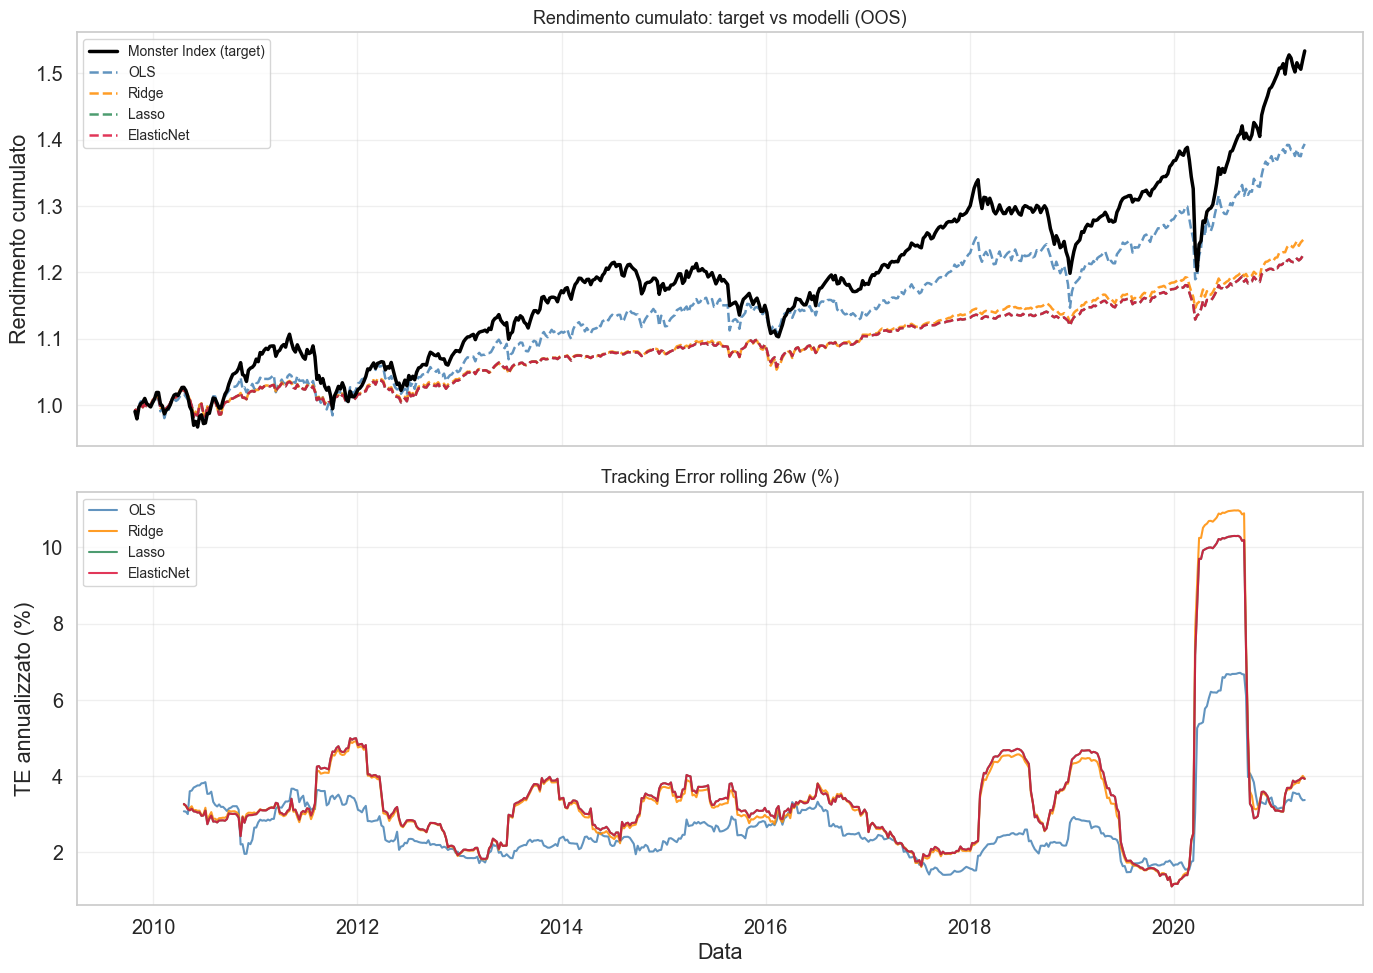

In [20]:
# ============================================================
# GRAFICO: rendimento cumulato + tracking error rolling
# ============================================================
modelli_lineari = {
    'OLS'        : ols_result,
    'Ridge'      : best_ridge_full,
    'Lasso'      : best_lasso_full,
    'ElasticNet' : best_en_full,
}
colori_lineari = ['steelblue','darkorange','seagreen','crimson']

date_comune = ols_result['replica_returns'].index
for res in modelli_lineari.values():
    date_comune = date_comune.intersection(res['replica_returns'].index)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

tgt_common = ols_result['target_returns'].loc[date_comune]
axes[0].plot((1+tgt_common).cumprod(), color='black', linewidth=2.5,
             label='Monster Index (target)', zorder=5)
for (nome, res), col in zip(modelli_lineari.items(), colori_lineari):
    r = res['replica_returns'].loc[date_comune]
    axes[0].plot((1+r).cumprod(), linewidth=1.8, linestyle='--', color=col, label=nome, alpha=0.85)

axes[0].set_title('Rendimento cumulato: target vs modelli (OOS)', fontsize=13)
axes[0].set_ylabel('Rendimento cumulato')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for (nome, res), col in zip(modelli_lineari.items(), colori_lineari):
    r = res['replica_returns'].loc[date_comune]
    te_roll = (r - tgt_common).rolling(26).std() * np.sqrt(annual_factor) * 100
    axes[1].plot(te_roll, linewidth=1.5, color=col, label=nome, alpha=0.85)

axes[1].set_title('Tracking Error rolling 26w (%)', fontsize=13)
axes[1].set_ylabel('TE annualizzato (%)')
axes[1].set_xlabel('Data')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Analisi approfondita del modello lineare ottimale

In [21]:
# ============================================================
# SELEZIONE AUTOMATICA DEL MIGLIOR MODELLO LINEARE
# Criterio primario: correlazione OOS
# ============================================================
corr_per_modello = {
    'OLS'        : ols_result['correlation'],
    'Ridge'      : best_ridge_full['correlation'],
    'Lasso'      : best_lasso_full['correlation'],
    'ElasticNet' : best_en_full['correlation'],
}
best_lin_name = max(corr_per_modello, key=corr_per_modello.get)
best_lin_res  = {'OLS': ols_result, 'Ridge': best_ridge_full,
                 'Lasso': best_lasso_full, 'ElasticNet': best_en_full}[best_lin_name]

print(f"Miglior modello lineare: {best_lin_name}  (corr={best_lin_res['correlation']:.4f})")

rep = best_lin_res['replica_returns']
tgt = best_lin_res['target_returns']

Miglior modello lineare: OLS  (corr=0.8562)


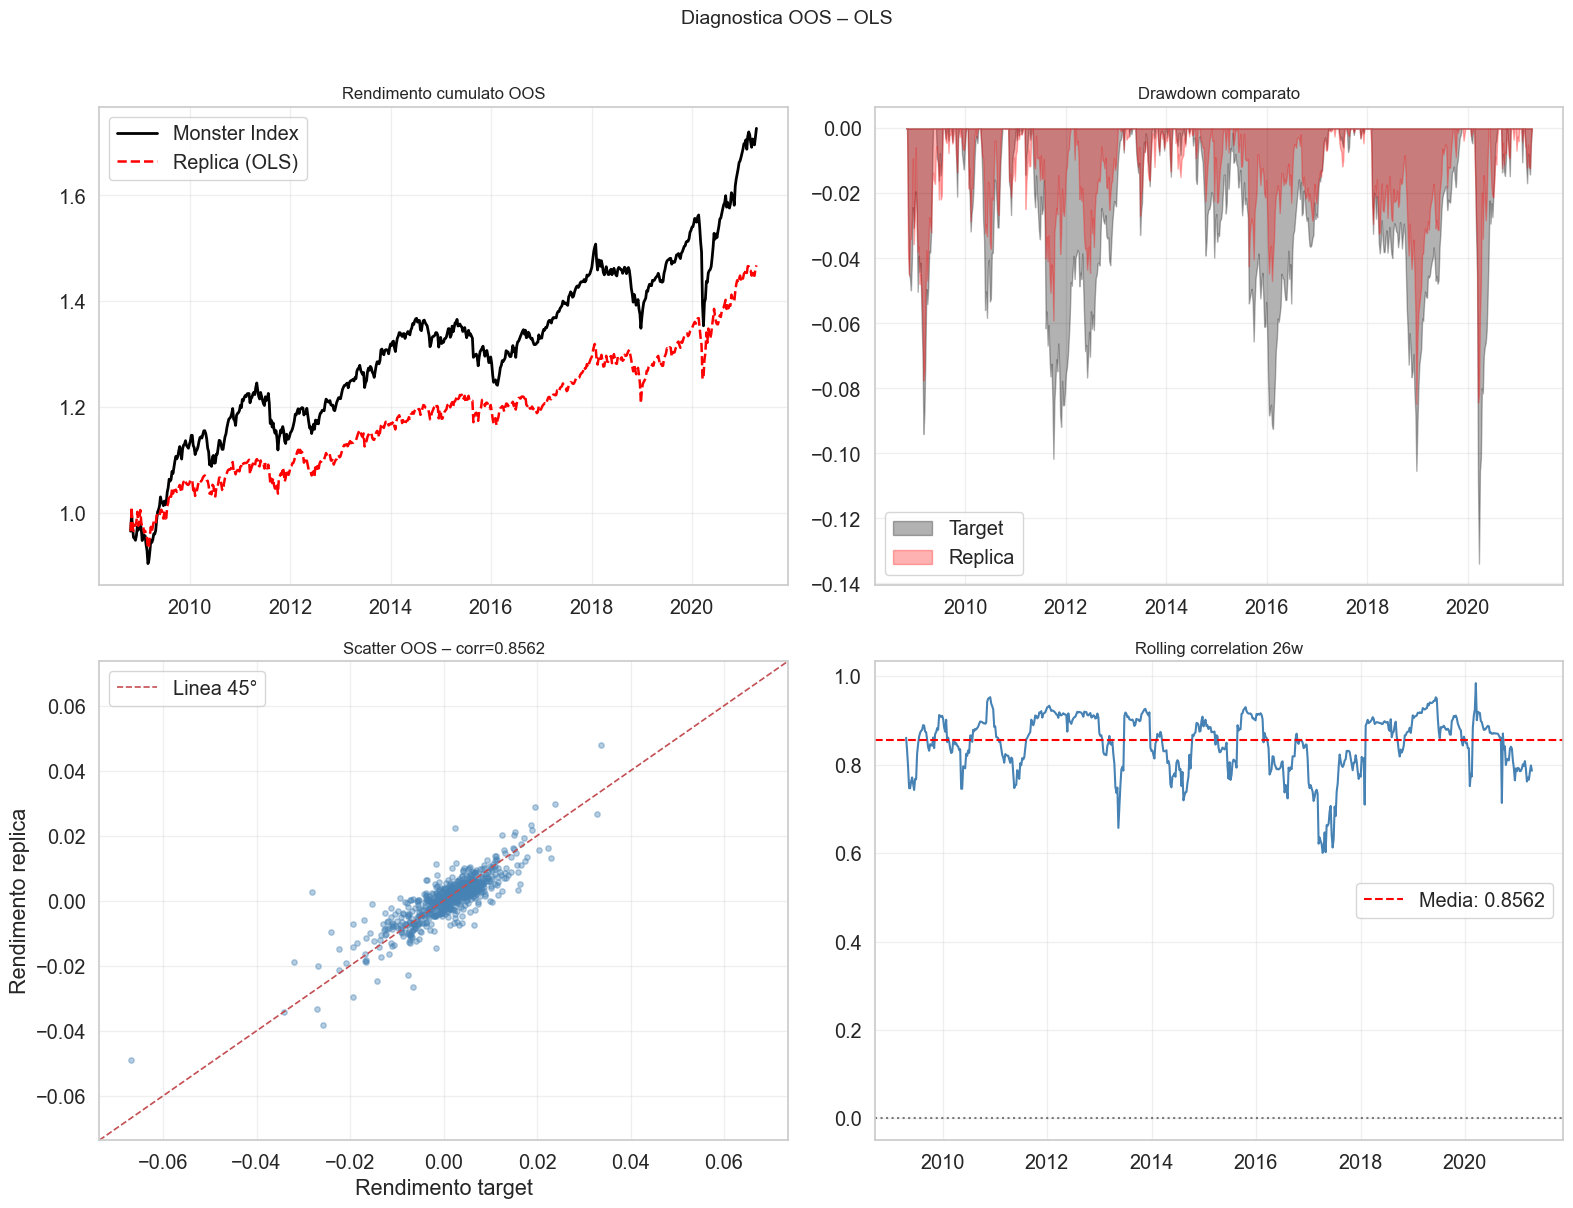

In [22]:
# ============================================================
# GRAFICI DIAGNOSTICI – 4 pannelli
# ============================================================
m = calcola_metriche(rep, tgt)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cum_rep = (1+rep).cumprod()
cum_tgt_loc = (1+tgt).cumprod()
axes[0,0].plot(cum_tgt_loc, color='black', linewidth=2, label='Monster Index')
axes[0,0].plot(cum_rep, color='red', linewidth=1.8, linestyle='--', label=f'Replica ({best_lin_name})')
axes[0,0].set_title('Rendimento cumulato OOS', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

dd_rep = 1 - cum_rep / cum_rep.cummax()
dd_tgt = 1 - cum_tgt_loc / cum_tgt_loc.cummax()
axes[0,1].fill_between(dd_tgt.index, 0, -dd_tgt, color='black', alpha=0.3, label='Target')
axes[0,1].fill_between(dd_rep.index, 0, -dd_rep, color='red',   alpha=0.3, label='Replica')
axes[0,1].set_title('Drawdown comparato', fontsize=12)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

lim = max(abs(tgt).max(), abs(rep).max()) * 1.1
axes[1,0].scatter(tgt, rep, alpha=0.4, s=15, color='steelblue')
axes[1,0].plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.2, label='Linea 45°')
axes[1,0].set_xlim(-lim, lim)
axes[1,0].set_ylim(-lim, lim)
axes[1,0].set_xlabel('Rendimento target')
axes[1,0].set_ylabel('Rendimento replica')
axes[1,0].set_title(f'Scatter OOS – corr={m["correlation"]:.4f}', fontsize=12)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

corr_roll = rep.rolling(26).corr(tgt)
axes[1,1].plot(corr_roll, color='steelblue', linewidth=1.5)
axes[1,1].axhline(y=m['correlation'], color='red', linestyle='--',
                   label=f'Media: {m["correlation"]:.4f}')
axes[1,1].axhline(y=0, color='black', linestyle=':', alpha=0.5)
axes[1,1].set_title('Rolling correlation 26w', fontsize=12)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Diagnostica OOS – {best_lin_name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

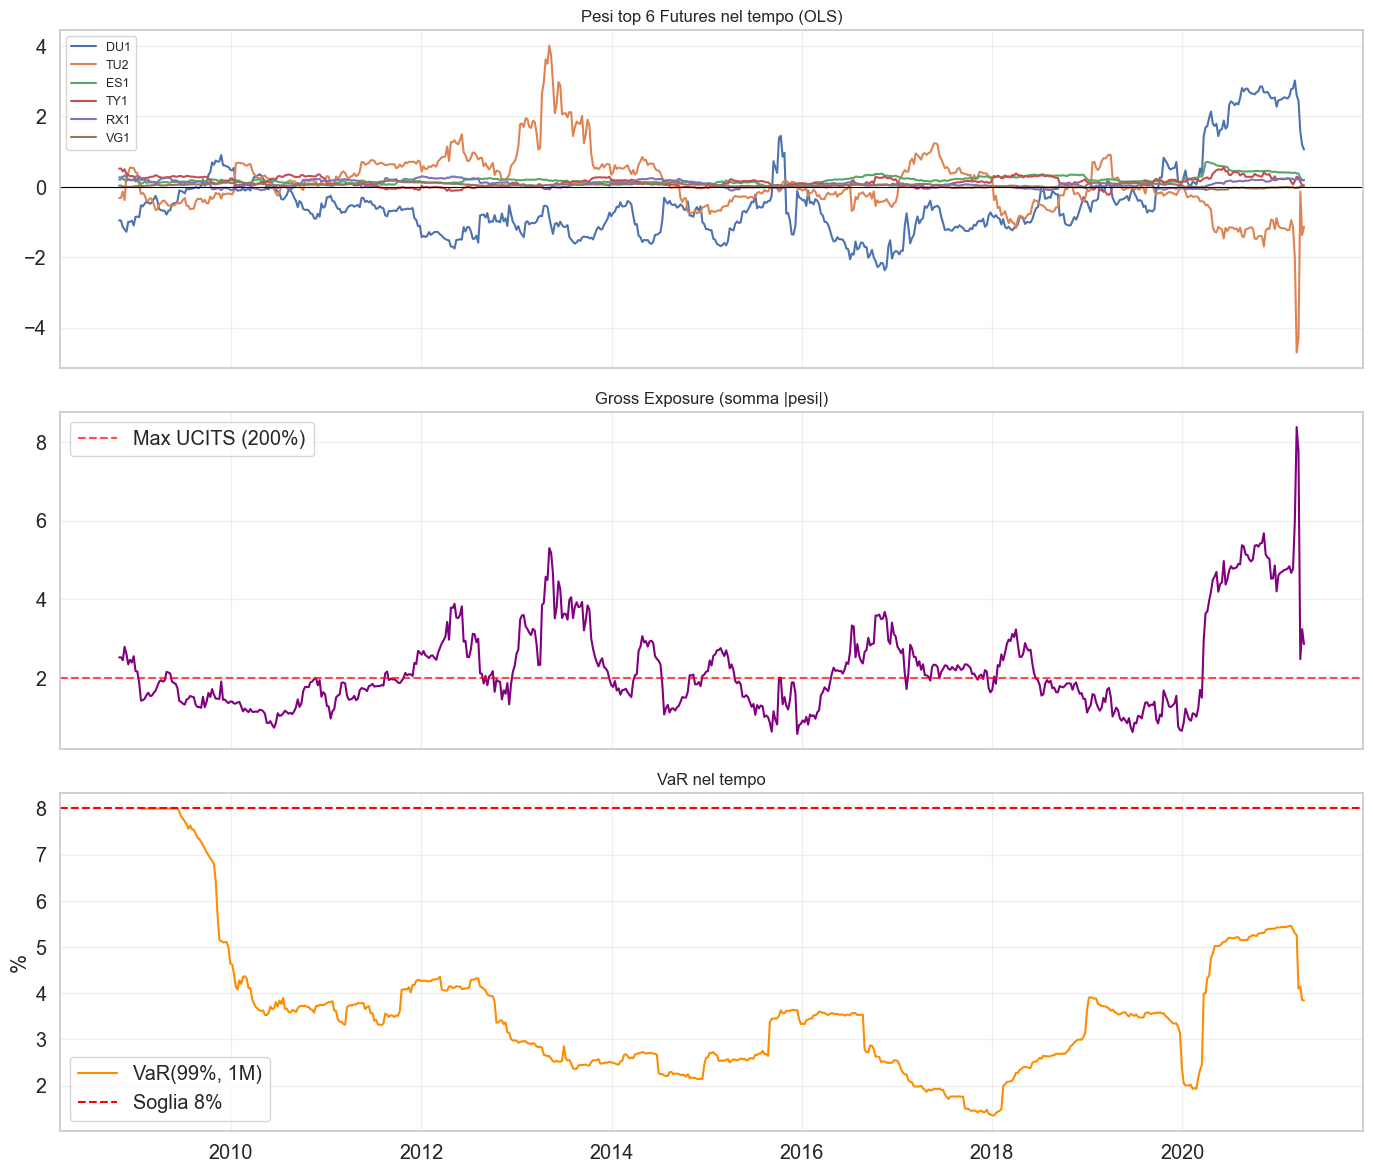

In [23]:
# ============================================================
# PESI NEL TEMPO + GROSS EXPOSURE + VaR
# ============================================================
if 'pesi_history' in best_lin_res:
    pesi_df = best_lin_res['pesi_history']
    top6    = pesi_df.abs().mean().sort_values(ascending=False).head(6).index

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    for col in top6:
        axes[0].plot(pesi_df[col], linewidth=1.5, label=col)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title(f'Pesi top 6 Futures nel tempo ({best_lin_name})', fontsize=12)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    ge = best_lin_res['gross_exposure']
    axes[1].plot(ge, color='purple', linewidth=1.5)
    axes[1].axhline(2.0, color='red', linestyle='--', alpha=0.7, label='Max UCITS (200%)')
    axes[1].set_title('Gross Exposure (somma |pesi|)', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    var_s = best_lin_res['var_history'].dropna()
    axes[2].plot(var_s*100, color='darkorange', linewidth=1.5, label='VaR(99%, 1M)')
    axes[2].axhline(VAR_MAX*100, color='red', linestyle='--',
                    label=f'Soglia {VAR_MAX*100:.0f}%')
    axes[2].set_title('VaR nel tempo', fontsize=12)
    axes[2].set_ylabel('%')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 9. Kalman Filter – Pesi Dinamici Adattativi

### Motivazione

I modelli rolling window riaddestrano il modello ogni settimana usando una finestra **fissa** di K osservazioni passate. Il Kalman Filter è un'alternativa più elegante: i pesi evolvono **continuamente** come un **random walk** e vengono aggiornati in modo ottimale a ogni nuova osservazione.

**Modello di stato:**
$$\beta_t = \beta_{t-1} + \eta_t \quad (\text{equazione di stato})$$
$$r_t^{target} = X_t^\top \beta_t + \epsilon_t \quad (\text{equazione di osservazione})$$

dove $\eta_t \sim \mathcal{N}(0, Q)$ è il rumore di processo e $\epsilon_t \sim \mathcal{N}(0, R)$ è il rumore di misura.

**Vantaggi rispetto al rolling window:**
- Nessun parametro di lunghezza finestra da ottimizzare
- I pesi si adattano istantaneamente a ogni nuova informazione
- Utilizza **tutta** la storia (con pesi decrescenti implicitamente)

In [24]:
# ============================================================
# KALMAN FILTER – implementazione manuale con numpy
# Evita dipendenze da librerie esterne (pykalman è deprecata)
# ============================================================

def kalman_filter_backtest(
    X_vals, y_vals, dates,
    Q_scale=1e-4,          # varianza del processo (quanto i pesi possono cambiare)
    R_scale=1e-2,          # varianza di osservazione (quanto è rumoroso il target)
    costo_transazione=0.0005
):
    """
    Replica tramite Kalman Filter.
    Inizializza i pesi a zero e aggiorna settimana per settimana.

    Parametri
    ---------
    Q_scale  : scala della matrice di covarianza del processo.
               Valore alto → i pesi cambiano rapidamente (tracking veloce ma instabile).
               Valore basso → i pesi cambiano lentamente (stabile ma lento).
    R_scale  : varianza del residuo di osservazione.
               Valore alto → diamo meno credito alle osservazioni recenti.

    Ritorna  : dizionario compatibile con backtest_rolling
    """
    n_obs, n_features = X_vals.shape

    # Inizializzazione del filtro
    beta   = np.zeros(n_features)                      # Stima iniziale pesi
    P      = np.eye(n_features) * 1.0                  # Covarianza iniziale (incertezza alta)
    Q      = np.eye(n_features) * Q_scale              # Covarianza del processo (random walk)
    R      = R_scale                                    # Varianza di osservazione (scalare)

    replica_ret  = []
    rep_dates    = []
    pesi_hist    = []
    gross_exp    = []
    var_hist     = []
    turnover_h   = []
    pesi_prev    = np.zeros(n_features)

    # Periodo di warm-up: usiamo le prime 52 osservazioni per inizializzare,
    # poi produciamo previsioni OOS dalla settimana 53 in poi.
    warmup = 52

    for t in range(n_obs - 1):
        x_t = X_vals[t]    # Rendimenti Futures settimana t
        y_t = y_vals[t]    # Rendimento target settimana t

        # ---- PREDICT ----
        # I pesi evolvono come random walk: beta_{t|t-1} = beta_{t-1|t-1}
        # La covarianza cresce di Q ad ogni passo (incertezza aumenta)
        P_pred = P + Q

        # ---- UPDATE (Kalman gain) ----
        # S = varianza della previsione del rendimento
        S  = x_t @ P_pred @ x_t + R           # Scalare
        K  = P_pred @ x_t / S                 # Kalman gain (vettore N_features)

        # Aggiornamento stime: correzione basata sull'errore di previsione
        innovation = y_t - x_t @ beta          # Errore previsione (scalare)
        beta       = beta + K * innovation     # Pesi aggiornati
        P          = (np.eye(n_features) - np.outer(K, x_t)) @ P_pred  # Covarianza aggiornata

        # Vincolo VaR (identico agli altri modelli)
        if t >= warmup and len(replica_ret) >= 12:
            storico = np.array(replica_ret[-min(52, len(replica_ret)):])
            pesi_out = beta.copy()
            var_est  = calcola_var_gaussiana(storico, VAR_CONFIDENCE, VAR_HORIZON)
            if var_est > VAR_MAX:
                pesi_out *= VAR_MAX / var_est
                var_est   = VAR_MAX
            var_hist.append(var_est)
        else:
            pesi_out = beta.copy()
            var_hist.append(np.nan)

        # Previsione OOS: usiamo i pesi aggiornati su x_{t+1}
        if t >= warmup:
            x_next    = X_vals[t + 1]
            turnover  = np.sum(np.abs(pesi_out - pesi_prev))
            ret_netto = np.dot(x_next, pesi_out) - costo_transazione * turnover

            replica_ret.append(ret_netto)
            rep_dates.append(dates[t + 1])
            pesi_hist.append(pesi_out.copy())
            gross_exp.append(np.sum(np.abs(pesi_out)))
            turnover_h.append(turnover)
            pesi_prev = pesi_out.copy()

    replica_series = pd.Series(replica_ret, index=rep_dates)
    target_series  = target_aligned.loc[replica_series.index]
    metriche       = calcola_metriche(replica_series, target_series)

    return {
        **metriche,
        'avg_turnover'     : np.mean(turnover_h),
        'replica_returns'  : replica_series,
        'target_returns'   : target_series,
        'pesi_history'     : pd.DataFrame(pesi_hist, index=rep_dates, columns=futures_contracts),
        'gross_exposure'   : pd.Series(gross_exp, index=rep_dates),
        'var_history'      : pd.Series(var_hist[-len(rep_dates):], index=rep_dates),
        'turnover_history' : pd.Series(turnover_h, index=rep_dates),
    }


print("Funzione kalman_filter_backtest definita.")

Funzione kalman_filter_backtest definita.


In [25]:
# ============================================================
# GRID SEARCH KALMAN – scansione di Q_scale e R_scale
# ============================================================
kf_Q_scales = [1e-5, 1e-4, 1e-3]
kf_R_scales = [1e-3, 1e-2, 1e-1]

kf_results = []
print("Grid search Kalman Filter...")

for Q_s, R_s in product(kf_Q_scales, kf_R_scales):
    res = kalman_filter_backtest(X_vals, y_vals, dates, Q_scale=Q_s, R_scale=R_s)
    kf_results.append({
        'Q_scale': Q_s, 'R_scale': R_s,
        **{k:v for k,v in res.items() if not isinstance(v,(pd.Series,pd.DataFrame))}
    })

kf_df = pd.DataFrame(kf_results).sort_values('correlation', ascending=False)
print("\nTop 5 Kalman Filter:")
display(kf_df[['Q_scale','R_scale','correlation','tracking_error','info_ratio','sharpe']].head(5).round(4))

Grid search Kalman Filter...

Top 5 Kalman Filter:


,Q_scale,R_scale,correlation,tracking_error,info_ratio,sharpe
4,0.0001,0.010,0.8710,0.0293,-0.2358,0.7826
1,0.0000,0.010,0.8707,0.0294,-0.2389,0.7773
7,0.0010,0.010,0.8689,0.0296,-0.1742,0.8065
0,0.0000,0.001,0.8669,0.0299,-0.1886,0.7814
3,0.0001,0.001,0.8647,0.0302,-0.1439,0.8021


Kalman Filter ottimale: Q=0.0001, R=0.01
  Correlazione OOS  : 0.8710
  Tracking Error    : 2.93%
  Information Ratio : -0.236
  Turnover medio    : 0.0058


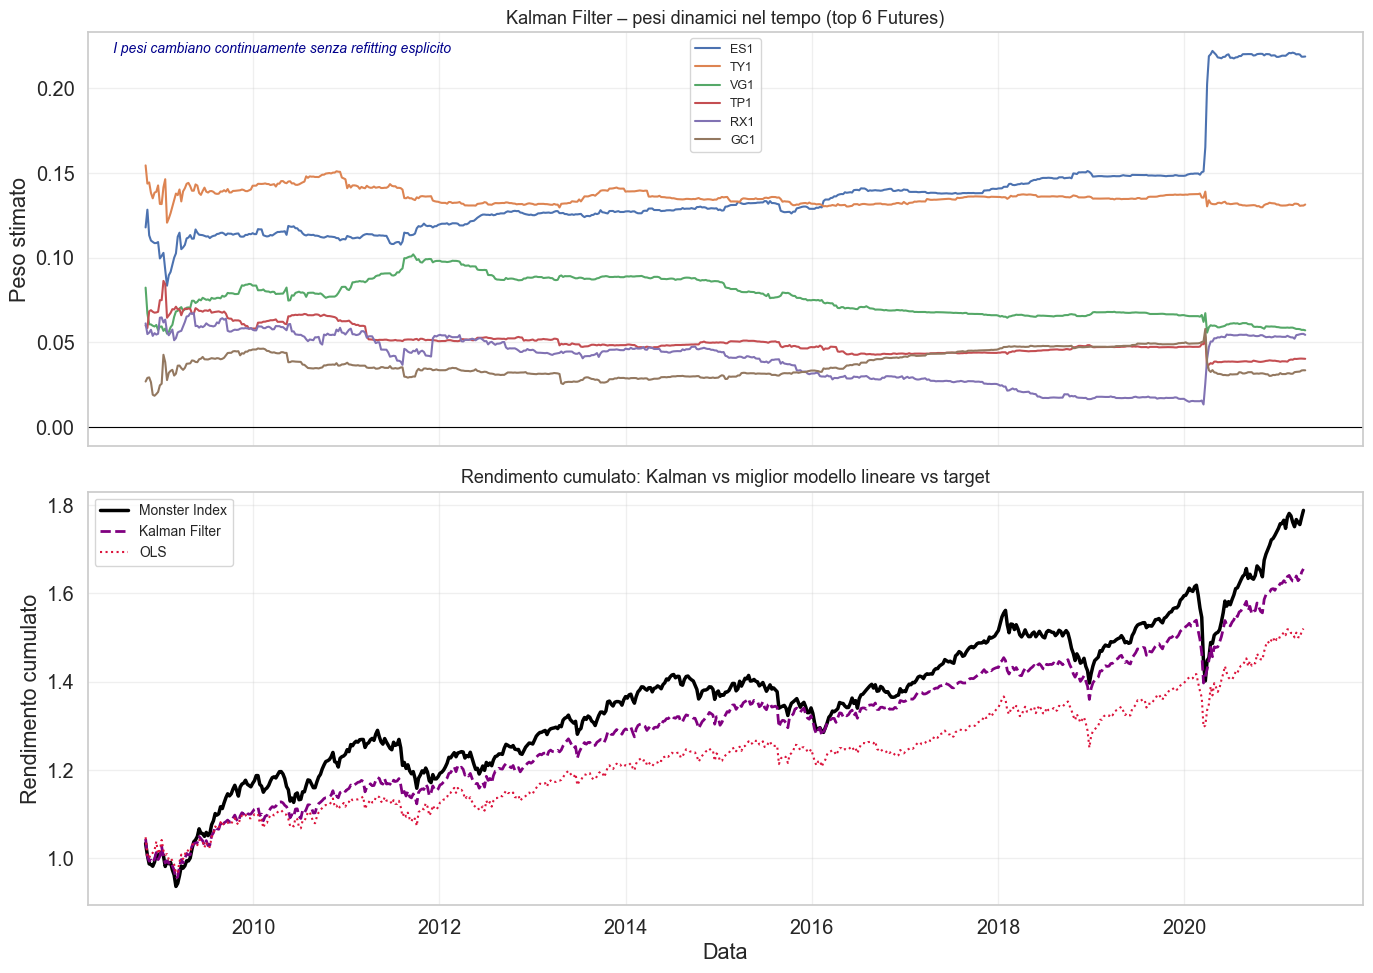

In [26]:
# ============================================================
# BEST KALMAN – analisi dei pesi dinamici
# ============================================================
best_kf_row = kf_df.iloc[0]
kf_best = kalman_filter_backtest(
    X_vals, y_vals, dates,
    Q_scale=best_kf_row['Q_scale'],
    R_scale=best_kf_row['R_scale']
)

print(f"Kalman Filter ottimale: Q={best_kf_row['Q_scale']}, R={best_kf_row['R_scale']}")
print(f"  Correlazione OOS  : {kf_best['correlation']:.4f}")
print(f"  Tracking Error    : {kf_best['tracking_error']*100:.2f}%")
print(f"  Information Ratio : {kf_best['info_ratio']:.3f}")
print(f"  Turnover medio    : {kf_best['avg_turnover']:.4f}")

# Grafico pesi dinamici – i pesi cambiano continuamente senza jump
pesi_kf = kf_best['pesi_history']
top6_kf = pesi_kf.abs().mean().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for col in top6_kf:
    axes[0].plot(pesi_kf[col], linewidth=1.5, label=col)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Kalman Filter – pesi dinamici nel tempo (top 6 Futures)', fontsize=13)
axes[0].set_ylabel('Peso stimato')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('I pesi cambiano continuamente senza refitting esplicito',
                  xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10,
                  color='darkblue', style='italic')

# Confronto rendimento cumulato: Kalman vs miglior modello lineare vs target
common_kf = kf_best['replica_returns'].index.intersection(rep.index)
axes[1].plot((1+target_aligned.loc[common_kf]).cumprod(), color='black',
             linewidth=2.5, label='Monster Index')
axes[1].plot((1+kf_best['replica_returns'].loc[common_kf]).cumprod(),
             color='purple', linewidth=2, linestyle='--', label='Kalman Filter')
axes[1].plot((1+rep.loc[common_kf]).cumprod(),
             color='crimson', linewidth=1.5, linestyle=':', label=f'{best_lin_name}')
axes[1].set_title('Rendimento cumulato: Kalman vs miglior modello lineare vs target', fontsize=13)
axes[1].set_ylabel('Rendimento cumulato')
axes[1].set_xlabel('Data')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Analisi per periodi di crisi

Testare la robustezza del modello su periodi di stress specifici è fondamentale: un modello che funziona bene in media ma crolla nelle crisi è inaccettabile in finanza.

| Crisi | Periodo | Causa principale |
|-------|---------|------------------|
| GFC 2008 | Ago 2008 – Mar 2009 | Collasso Lehman Brothers / credit crunch |
| Crisi Eurozona | Lug 2011 – Dic 2011 | Spread BTP-Bund, crisi debito sovrano |
| COVID-19 | Feb 2020 – Apr 2020 | Lockdown globale, crash liquidità |
| Inflazione 2022 | Gen 2022 – Dic 2022 | Rialzi tassi Fed/BCE, guerra Ucraina |

In [27]:
# ============================================================
# DEFINIZIONE PERIODI DI CRISI
# ============================================================
crisis_periods = {
    'GFC 2008'           : ('2008-08-01', '2009-03-31'),
    'Eurozona 2011'      : ('2011-07-01', '2011-12-31'),
    'COVID-19 2020'      : ('2020-02-01', '2020-04-30'),
    'Inflazione 2022'    : ('2022-01-01', '2022-12-31'),
}

# ============================================================
# FUNZIONE: metriche su sottoperiodo
# ============================================================
def metriche_sottoperiodo(result_dict, start, end):
    """
    Estrae le metriche di un backtest limitandosi al sottoperiodo [start, end].
    Ritorna None se non ci sono dati sufficienti nel periodo.
    """
    rep_sub = result_dict['replica_returns'].loc[start:end]
    tgt_sub = result_dict['target_returns'].loc[start:end]

    if len(rep_sub) < 4:   # almeno 4 osservazioni per avere senso
        return None

    return calcola_metriche(rep_sub, tgt_sub)


# ============================================================
# CALCOLO METRICHE PER OGNI CRISI E OGNI MODELLO
# ============================================================
tutti_i_modelli = {
    'OLS'          : ols_result,
    'Ridge'        : best_ridge_full,
    'Lasso'        : best_lasso_full,
    'ElasticNet'   : best_en_full,
    'Kalman Filter': kf_best,
}

# Metriche da estrarre per il confronto
metriche_da_mostrare = ['correlation', 'tracking_error', 'info_ratio', 'max_drawdown']

print("Analisi per periodi di crisi – Correlazione OOS\n")
print(f"{'Crisi':<22} ", end='')
for nome in tutti_i_modelli:
    print(f"{nome:>14}", end='')
print()
print("-" * (22 + 14 * len(tutti_i_modelli)))

crisis_results = {}  # salviamo per i grafici
for crisi, (start, end) in crisis_periods.items():
    crisis_results[crisi] = {}
    print(f"{crisi:<22} ", end='')
    for nome, res in tutti_i_modelli.items():
        m_sub = metriche_sottoperiodo(res, start, end)
        if m_sub is not None:
            corr_val = m_sub['correlation']
            crisis_results[crisi][nome] = m_sub
            print(f"{corr_val:>14.4f}", end='')
        else:
            crisis_results[crisi][nome] = None
            print(f"{'N/A':>14}", end='')
    print()

Analisi per periodi di crisi – Correlazione OOS

Crisi                             OLS         Ridge         Lasso    ElasticNet Kalman Filter
--------------------------------------------------------------------------------------------
GFC 2008                       0.8583           N/A           N/A           N/A        0.8977
Eurozona 2011                  0.9244        0.9176        0.9098        0.9098        0.9490
COVID-19 2020                  0.9061        0.6635        0.7562        0.7562        0.8013
Inflazione 2022                   N/A           N/A           N/A           N/A           N/A


In [28]:
# ============================================================
# TABELLA COMPLETA: metriche per crisi e modello
# ============================================================
rows = []
for crisi, (start, end) in crisis_periods.items():
    for nome, res in tutti_i_modelli.items():
        m_sub = metriche_sottoperiodo(res, start, end)
        if m_sub is None:
            continue
        rows.append({
            'Crisi'   : crisi,
            'Modello' : nome,
            'Corr.'   : round(m_sub['correlation'], 4),
            'TE (%)'  : round(m_sub['tracking_error'] * 100, 2),
            'IR'      : round(m_sub['info_ratio'], 3),
            'MDD (%)' : round(m_sub['max_drawdown'] * 100, 2),
        })

crisis_tab = pd.DataFrame(rows).set_index(['Crisi', 'Modello'])
print("Metriche per periodo di crisi:")
display(crisis_tab)

Metriche per periodo di crisi:


Corr.  TE (%)     IR  MDD (%)
Crisi         Modello                                      
GFC 2008      OLS            0.8583    7.47  0.666     7.76
              Kalman Filter  0.8977    5.71  0.540     8.58
Eurozona 2011 OLS            0.9244    3.31  2.650     5.13
              Ridge          0.9176    4.92  1.504     3.14
              Lasso          0.9098    5.00  1.471     3.20
              ElasticNet     0.9098    5.00  1.471     3.20
              Kalman Filter  0.9490    2.88  2.974     4.84
COVID-19 2020 OLS            0.9061    7.78  2.915     8.43
              Ridge          0.6635   14.98  1.285     3.91
              Lasso          0.7562   14.03  1.310     4.39
              ElasticNet     0.7562   14.03  1.310     4.39
              Kalman Filter  0.8013   10.88  1.167     9.24

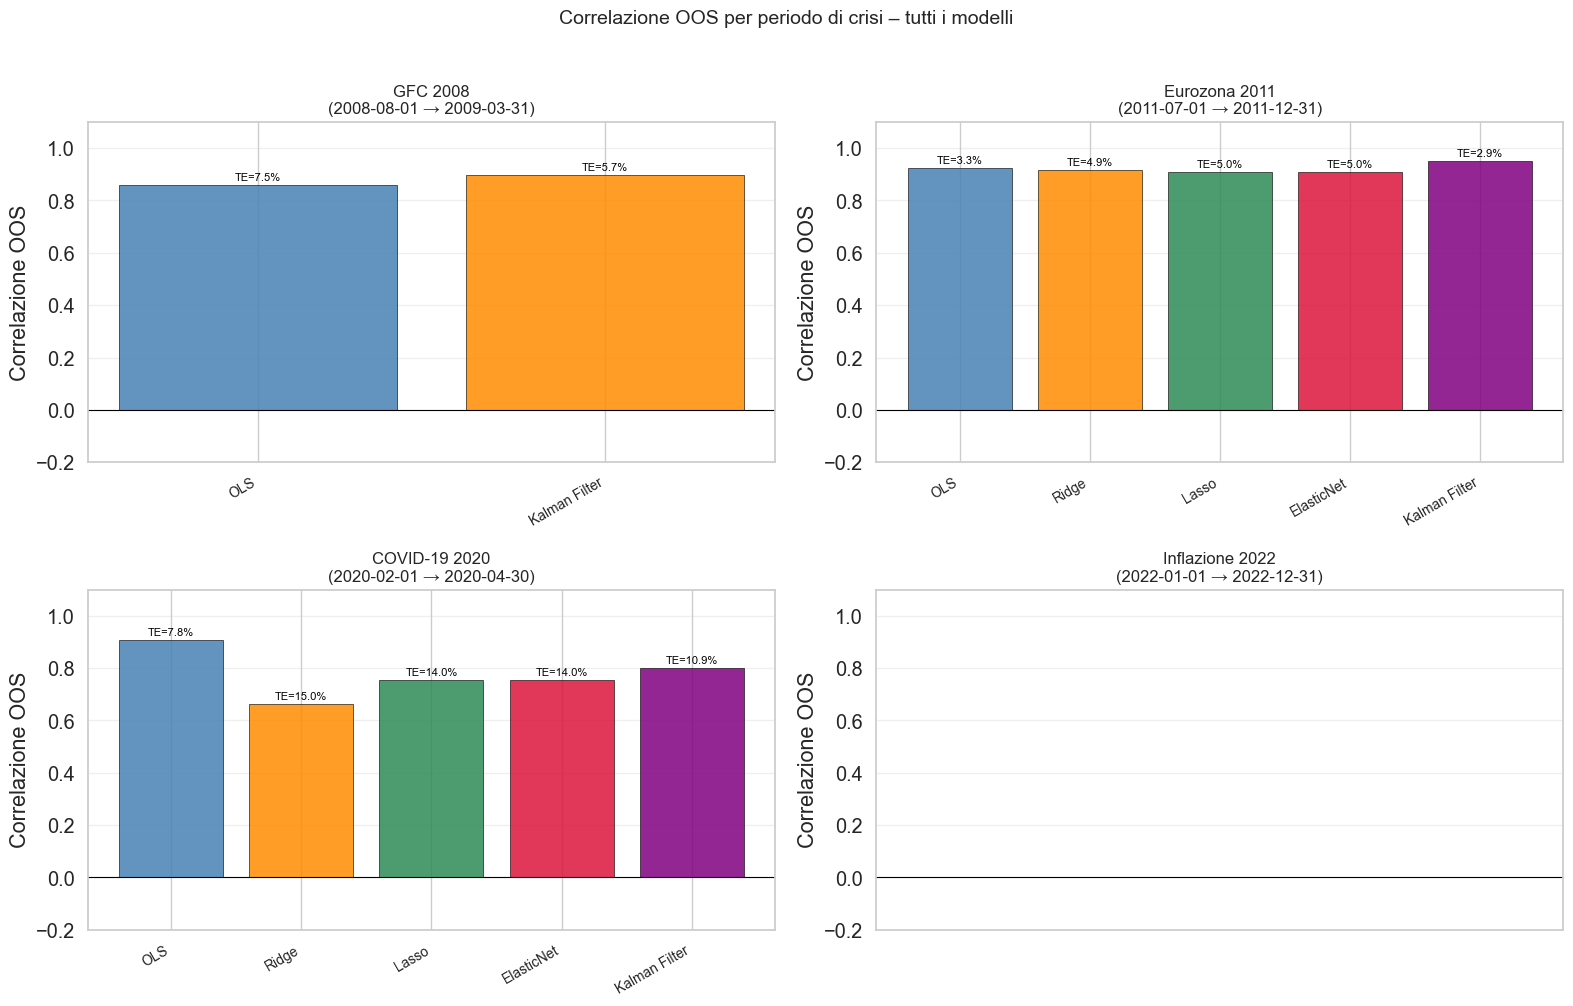

In [29]:
# ============================================================
# GRAFICO: correlazione per crisi – barchart comparativo
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colori_modelli = ['steelblue','darkorange','seagreen','crimson','purple']

for ax_idx, (crisi, (start, end)) in enumerate(crisis_periods.items()):
    nomi, corrs, tes = [], [], []
    for nome, res in tutti_i_modelli.items():
        m_sub = metriche_sottoperiodo(res, start, end)
        if m_sub is not None:
            nomi.append(nome)
            corrs.append(m_sub['correlation'])
            tes.append(m_sub['tracking_error'] * 100)

    x = np.arange(len(nomi))
    bars = axes[ax_idx].bar(x, corrs,
                             color=colori_modelli[:len(nomi)],
                             edgecolor='black', linewidth=0.5, alpha=0.85)

    # Annotazione TE sopra ogni barra
    for bar, te in zip(bars, tes):
        axes[ax_idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'TE={te:.1f}%',
            ha='center', va='bottom', fontsize=8, color='black'
        )

    axes[ax_idx].set_title(f'{crisi}\n({start} → {end})', fontsize=12)
    axes[ax_idx].set_ylabel('Correlazione OOS')
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(nomi, rotation=30, ha='right', fontsize=10)
    axes[ax_idx].axhline(y=0, color='black', linewidth=0.8)
    axes[ax_idx].set_ylim(-0.2, 1.1)
    axes[ax_idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Correlazione OOS per periodo di crisi – tutti i modelli', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

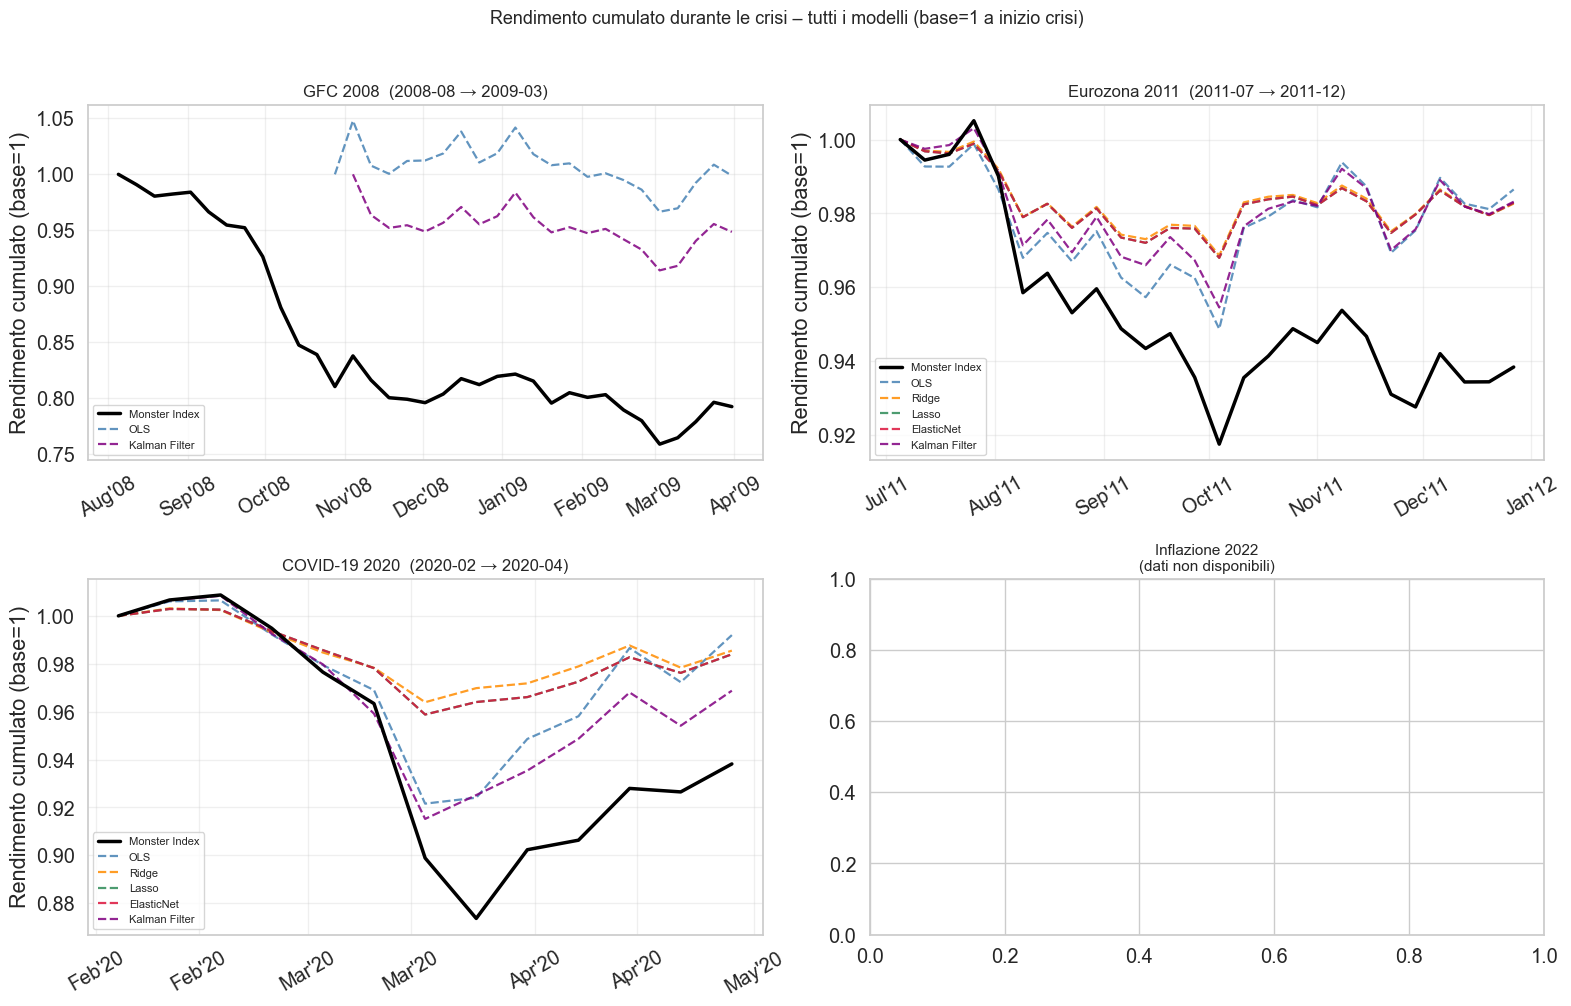

In [30]:
# ============================================================
# GRAFICO: rendimento cumulato durante ogni crisi
# Mostra graficamente chi segue meglio il target nei momenti difficili
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax_idx, (crisi, (start, end)) in enumerate(crisis_periods.items()):
    tgt_sub = target_aligned.loc[start:end]
    if len(tgt_sub) < 2:
        axes[ax_idx].set_title(f'{crisi}\n(dati non disponibili)', fontsize=11)
        continue

    # Target normalizzato a 1 all'inizio del periodo
    cum_tgt_sub = (1 + tgt_sub).cumprod()
    cum_tgt_sub = cum_tgt_sub / cum_tgt_sub.iloc[0]
    axes[ax_idx].plot(cum_tgt_sub, color='black', linewidth=2.5,
                      label='Monster Index', zorder=5)

    for (nome, res), col in zip(tutti_i_modelli.items(), colori_modelli):
        rep_sub = res['replica_returns'].loc[start:end]
        if len(rep_sub) < 2:
            continue
        cum_rep_sub = (1 + rep_sub).cumprod()
        cum_rep_sub = cum_rep_sub / cum_rep_sub.iloc[0]
        axes[ax_idx].plot(cum_rep_sub, linewidth=1.6, linestyle='--',
                           color=col, label=nome, alpha=0.85)

    axes[ax_idx].set_title(f'{crisi}  ({start[:7]} → {end[:7]})', fontsize=12)
    axes[ax_idx].set_ylabel('Rendimento cumulato (base=1)')
    axes[ax_idx].legend(fontsize=8, loc='lower left')
    axes[ax_idx].grid(True, alpha=0.3)
    axes[ax_idx].xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
    axes[ax_idx].tick_params(axis='x', rotation=30)

plt.suptitle('Rendimento cumulato durante le crisi – tutti i modelli (base=1 a inizio crisi)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 11. Replication Score – Indice Composito

Una singola metrica non cattura tutta la qualità di una replica. Lo score composito combina 5 dimensioni con pesi che riflettono le priorità del gestore:

$$\text{Score} = 0.35 \cdot \rho + 0.20 \cdot \frac{1}{1+TE} + 0.20 \cdot \text{IR}_{\text{norm}} + 0.15 \cdot \frac{1}{1+\text{Turnover}} + 0.10 \cdot (1 - \text{MDD}_{\text{rel}})$$

| Componente | Peso | Razionale |
|-----------|------|----------|
| Correlazione ($\rho$) | 35% | Misura principale di fedeltà della replica |
| $1/(1+TE)$ | 20% | Tracking Error basso → replica precisa |
| IR normalizzato | 20% | Rendimento extra per unità di rischio attivo |
| $1/(1+\text{Turnover})$ | 15% | Penalizza alta frequenza di ribilanciamento |
| $1 - \text{MDD}_{\text{rel}}$ | 10% | Drawdown replica non deve eccedere quello del target |

In [31]:
# ============================================================
# REPLICATION SCORE – calcolo per tutti i modelli
# ============================================================

def calcola_replication_score(result_dict, weights=None):
    """
    Calcola il Replication Score composito (0-1, più alto = migliore replica).

    Tutti gli input vengono estratti dal result_dict prodotto da backtest_rolling
    o kalman_filter_backtest. I pesi sono configurabili.
    """
    if weights is None:
        weights = {
            'correlation' : 0.35,
            'tracking_error': 0.20,
            'info_ratio'  : 0.20,
            'turnover'    : 0.15,
            'mdd_rel'     : 0.10,
        }

    corr     = result_dict.get('correlation', 0)
    te       = result_dict.get('tracking_error', 1.0)
    ir       = result_dict.get('info_ratio', 0)
    turnover = result_dict.get('avg_turnover', 0)
    mdd_rel  = result_dict.get('mdd_rel', 1.0)      # Drawdown replica / drawdown target

    # Trasformazioni per portare tutto in [0,1], higher=better
    s_corr     = np.clip(corr, 0, 1)                # La correlazione è già in [-1,1]; clippiamo a [0,1]
    s_te       = 1 / (1 + te)                       # TE basso → prossimo a 1
    s_ir       = np.clip((ir + 1) / 2, 0, 1)        # Mappiamo IR=[-1,1] → [0,1]; valori negativi penalizzati
    s_turnover = 1 / (1 + turnover)                  # Turnover basso → prossimo a 1
    s_mdd      = np.clip(1 - mdd_rel, 0, 1)         # mdd_rel=1 → score 0; mdd_rel<1 → score positivo

    score = (
        weights['correlation']    * s_corr +
        weights['tracking_error'] * s_te   +
        weights['info_ratio']     * s_ir   +
        weights['turnover']       * s_turnover +
        weights['mdd_rel']        * s_mdd
    )

    # Dettaglio dei contributi (utile per presentazione)
    contributi = {
        'corr (35%)'     : weights['correlation']    * s_corr,
        'TE (20%)'       : weights['tracking_error'] * s_te,
        'IR (20%)'       : weights['info_ratio']     * s_ir,
        'Turnover (15%)' : weights['turnover']       * s_turnover,
        'MDD_rel (10%)'  : weights['mdd_rel']        * s_mdd,
    }
    return score, contributi


# ============================================================
# CALCOLO SCORE PER TUTTI I MODELLI
# ============================================================
print("=" * 60)
print("   REPLICATION SCORE COMPARATIVO")
print("=" * 60)

score_rows = []
contributi_rows = {}

for nome, res in tutti_i_modelli.items():
    score, contrib = calcola_replication_score(res)
    score_rows.append({
        'Modello'       : nome,
        'Score'         : round(score, 4),
        'Corr.'         : round(res['correlation'], 4),
        'TE (%)'        : round(res['tracking_error']*100, 2),
        'IR'            : round(res['info_ratio'], 3),
        'Turnover'      : round(res.get('avg_turnover', np.nan), 4),
        'MDD_rel'       : round(res.get('mdd_rel', np.nan), 3),
    })
    contributi_rows[nome] = contrib

score_df = pd.DataFrame(score_rows).set_index('Modello').sort_values('Score', ascending=False)

print("\nTabella Replication Score (ordinata per score):")
display(score_df)

best_overall_name = score_df.index[0]
print(f"\n→ MIGLIOR MODELLO secondo Replication Score: {best_overall_name}  (Score={score_df.loc[best_overall_name,'Score']:.4f})")

   REPLICATION SCORE COMPARATIVO

Tabella Replication Score (ordinata per score):


,Score,Corr.,TE (%),IR,Turnover,MDD_rel
Modello,,,,,,
Kalman Filter,0.7557,0.8710,2.93,-0.236,0.0058,0.690
ElasticNet,0.7305,0.7889,3.81,-0.538,0.0112,0.328
Lasso,0.7305,0.7889,3.81,-0.538,0.0112,0.328
Ridge,0.7302,0.7680,3.85,-0.490,0.0116,0.305
OLS,0.7025,0.8562,3.18,-0.413,0.3204,0.633



→ MIGLIOR MODELLO secondo Replication Score: Kalman Filter  (Score=0.7557)


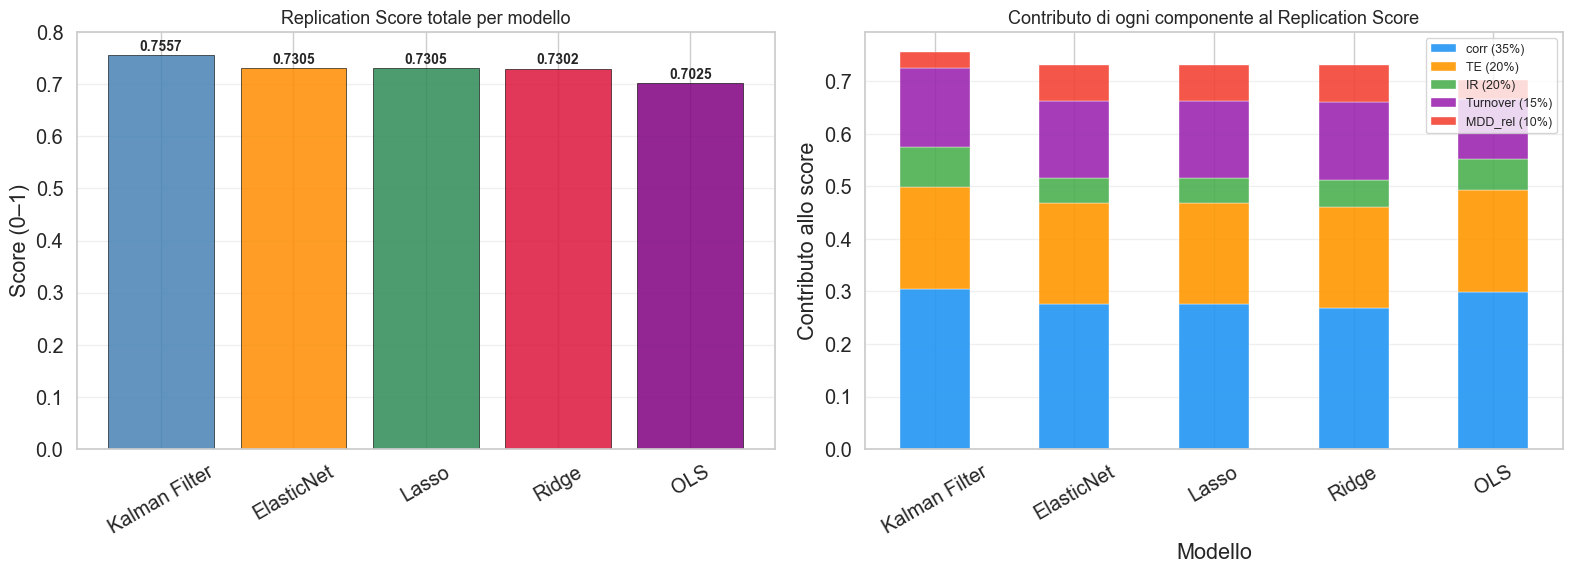

Interpretazione: la sezione più alta di ogni barra mostra quale componente
contribuisce di più al punteggio finale del modello.


In [32]:
# ============================================================
# VISUALIZZAZIONE DELLO SCORE – stacked bar (contributi)
# ============================================================
contrib_df = pd.DataFrame(contributi_rows).T  # modelli x componenti
contrib_df = contrib_df.loc[score_df.index]   # stesso ordine dello score_df

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Score totale ---
bars = axes[0].bar(
    score_df.index, score_df['Score'],
    color=colori_modelli[:len(score_df)],
    edgecolor='black', linewidth=0.5, alpha=0.85
)
for bar, val in zip(bars, score_df['Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                  f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Replication Score totale per modello', fontsize=13)
axes[0].set_ylabel('Score (0–1)')
axes[0].set_ylim(0, 0.8)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3, axis='y')

# --- Contributi per componente (stacked bar) ---
contrib_df.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#2196F3','#FF9800','#4CAF50','#9C27B0','#F44336'],
    edgecolor='white', linewidth=0.3, alpha=0.9
)
axes[1].set_title('Contributo di ogni componente al Replication Score', fontsize=13)
axes[1].set_ylabel('Contributo allo score')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Interpretazione: la sezione più alta di ogni barra mostra quale componente\n"
      "contribuisce di più al punteggio finale del modello.")

Replication Score per periodo di crisi:

Score per crisi (righe) x modello (colonne):


Modello,OLS,Ridge,Lasso,ElasticNet,Kalman Filter
Crisi,,,,,
COVID-19 2020,0.8425,0.8207,0.8527,0.8527,0.8381
Eurozona 2011,0.8855,0.9239,0.9201,0.9201,0.9199
GFC 2008,0.7732,NaN,NaN,NaN,0.8077


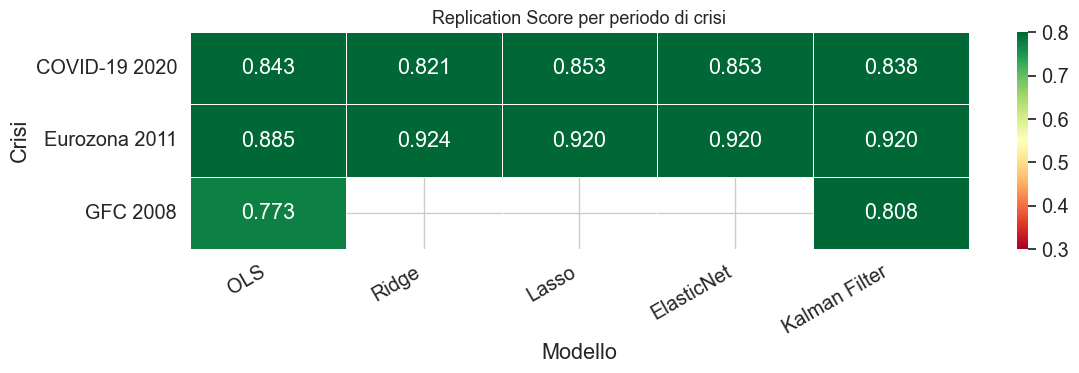

In [33]:
# ============================================================
# REPLICATION SCORE PER CRISI – robustezza in stress
# Verifica se il miglior modello globale mantiene la sua superiorità anche nelle crisi
# ============================================================
print("Replication Score per periodo di crisi:\n")

crisis_score_rows = []
for crisi, (start, end) in crisis_periods.items():
    for nome, res in tutti_i_modelli.items():
        m_sub = metriche_sottoperiodo(res, start, end)
        if m_sub is None:
            continue
        # Turnover medio nel sottoperiodo
        turn_sub = res['turnover_history'].loc[start:end]
        m_sub['avg_turnover'] = turn_sub.mean() if len(turn_sub) > 0 else res.get('avg_turnover', 0)

        score_c, _ = calcola_replication_score(m_sub)
        crisis_score_rows.append({
            'Crisi'   : crisi,
            'Modello' : nome,
            'Score'   : round(score_c, 4),
            'Corr.'   : round(m_sub['correlation'], 4),
            'TE (%)'  : round(m_sub['tracking_error']*100, 2),
        })

crisis_score_df = pd.DataFrame(crisis_score_rows)
# Pivot: righe = crisi, colonne = modelli, valori = score
pivot = crisis_score_df.pivot(index='Crisi', columns='Modello', values='Score')
pivot = pivot[list(tutti_i_modelli.keys())]

print("Score per crisi (righe) x modello (colonne):")
display(pivot.round(4))

# Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.3, vmax=0.8, linewidths=0.5)
plt.title('Replication Score per periodo di crisi', fontsize=13)
plt.xlabel('Modello')
plt.ylabel('Crisi')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 12. Insight aggiuntivi

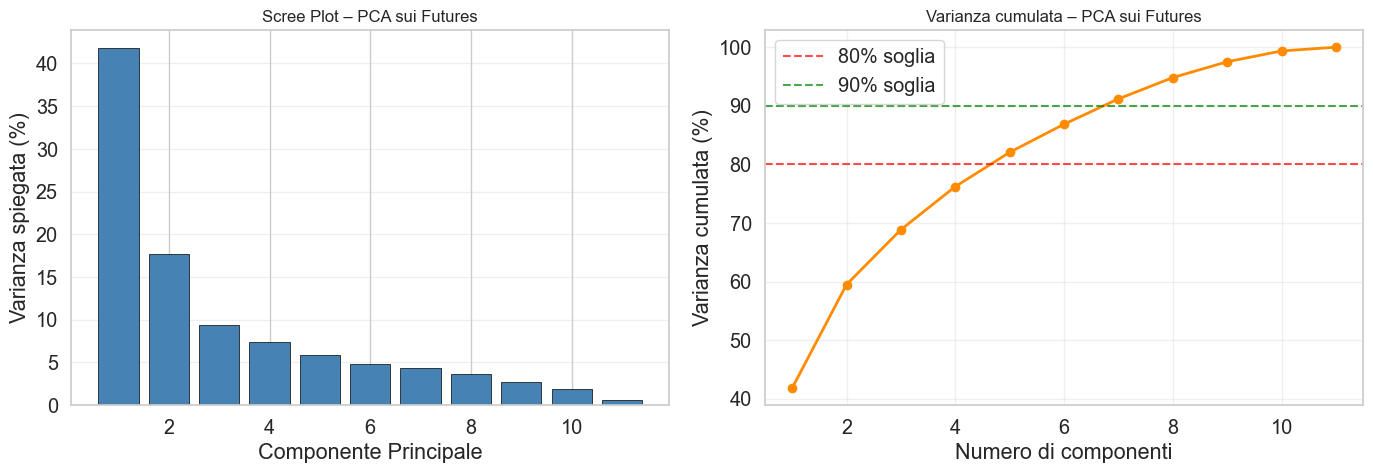

Componenti per 80% var.: 5
Componenti per 90% var.: 7
→ I Futures non sono tutti indipendenti: giustifica la regolarizzazione.


In [34]:
# ============================================================
# PCA SUI FUTURES – struttura fattoriale latente
# Quanti fattori indipendenti ci sono davvero tra gli 11 Futures?
# ============================================================
scaler_pca = StandardScaler()
X_std = scaler_pca.fit_transform(futures_ret.dropna())

pca = PCA()
pca.fit(X_std)

var_spiegata = pca.explained_variance_ratio_
var_cumulata = np.cumsum(var_spiegata)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(var_spiegata)+1), var_spiegata*100,
            color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Componente Principale')
axes[0].set_ylabel('Varianza spiegata (%)')
axes[0].set_title('Scree Plot – PCA sui Futures', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(range(1, len(var_cumulata)+1), var_cumulata*100,
             marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% soglia')
axes[1].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='90% soglia')
axes[1].set_xlabel('Numero di componenti')
axes[1].set_ylabel('Varianza cumulata (%)')
axes[1].set_title('Varianza cumulata – PCA sui Futures', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Componenti per 80% var.: {np.argmax(var_cumulata >= 0.80) + 1}")
print(f"Componenti per 90% var.: {np.argmax(var_cumulata >= 0.90) + 1}")
print("→ I Futures non sono tutti indipendenti: giustifica la regolarizzazione.")

In [35]:
# ============================================================
# ANALISI PER REGIME DI VOLATILITÀ
# ============================================================
vol_msci  = returns['MXWO'].rolling(26).std() * np.sqrt(annual_factor)
vol_msci  = vol_msci.loc[rep.index]
soglia    = vol_msci.median()

regime_alta  = vol_msci > soglia
regime_bassa = ~regime_alta

rows_reg = []
for nome, res in tutti_i_modelli.items():
    r_sub   = res['replica_returns'].reindex(vol_msci.index).dropna()
    t_sub   = res['target_returns'].reindex(vol_msci.index).dropna()
    reg_a   = regime_alta.reindex(r_sub.index).fillna(False)
    reg_b   = regime_bassa.reindex(r_sub.index).fillna(False)
    rows_reg.append({
        'Modello'          : nome,
        'Corr. Alta Vol.'  : round(r_sub[reg_a].corr(t_sub[reg_a]), 4),
        'Corr. Bassa Vol.' : round(r_sub[reg_b].corr(t_sub[reg_b]), 4),
        'TE Alta (%)'      : round((r_sub[reg_a]-t_sub[reg_a]).std()*np.sqrt(annual_factor)*100, 2),
        'TE Bassa (%)'     : round((r_sub[reg_b]-t_sub[reg_b]).std()*np.sqrt(annual_factor)*100, 2),
    })

print("Performance per regime di volatilità (alta vs bassa):")
display(pd.DataFrame(rows_reg).set_index('Modello'))

Performance per regime di volatilità (alta vs bassa):


,Corr. Alta Vol.,Corr. Bassa Vol.,TE Alta (%),TE Bassa (%)
Modello,,,,
OLS,0.8620,0.8370,3.85,2.34
Ridge,0.7883,0.7236,4.58,3.10
Lasso,0.8131,0.7406,4.49,3.14
ElasticNet,0.8131,0.7406,4.49,3.14
Kalman Filter,0.8781,0.8485,3.52,2.20


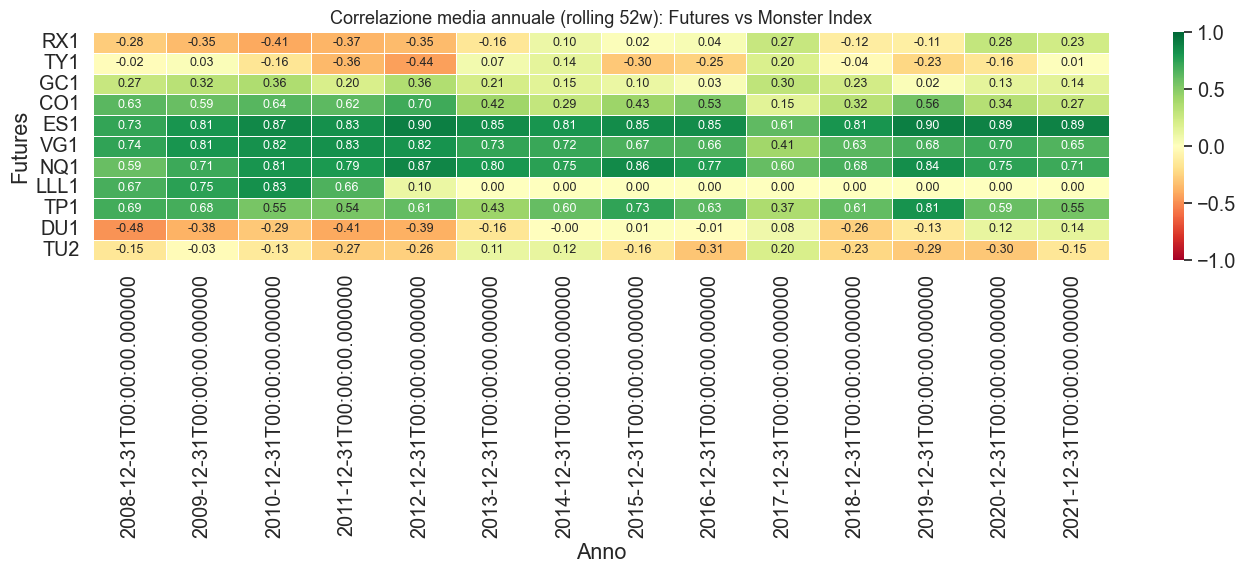

In [36]:
# ============================================================
# HEATMAP: correlazione annuale rolling (tutti Futures vs target)
# ============================================================
corr_roll_all = pd.DataFrame(index=futures_ret.index)
for col in futures_contracts:
    df_tmp = pd.DataFrame({'T': target_aligned, 'F': futures_ret[col]})
    corr_roll_all[col] = df_tmp['T'].rolling(52).corr(df_tmp['F'])

corr_ann = corr_roll_all.dropna().resample('YE').mean()

plt.figure(figsize=(14, 6))
sns.heatmap(corr_ann.T, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlazione media annuale (rolling 52w): Futures vs Monster Index', fontsize=13)
plt.xlabel('Anno')
plt.ylabel('Futures')
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# SENSITIVITÀ AI COSTI DI TRANSAZIONE
# ============================================================
costi_bps = [0, 1, 3, 5, 10]

best_overall_res = tutti_i_modelli[best_overall_name]
is_kalman = (best_overall_name == 'Kalman Filter')

print(f"Sensitività costi – modello: {best_overall_name}")
print(f"{'Costo (bps)':>12} | {'Return ann. (%)':>16} | {'Corr.':>8} | {'Score':>8}")
print("-" * 52)

for bps in costi_bps:
    costo_pct = bps / 10000

    if is_kalman:
        res_tmp = kalman_filter_backtest(
            X_vals, y_vals, dates,
            Q_scale=best_kf_row['Q_scale'],
            R_scale=best_kf_row['R_scale'],
            costo_transazione=costo_pct
        )
    else:
        model_map = {
            'OLS'        : LinearRegression(fit_intercept=False),
            'Ridge'      : Ridge(alpha=best_ridge['alpha'], fit_intercept=False),
            'Lasso'      : Lasso(alpha=best_lasso['alpha'], fit_intercept=False, max_iter=10000),
            'ElasticNet' : ElasticNet(alpha=best_en['alpha'], l1_ratio=best_en['l1_ratio'],
                                      fit_intercept=False, max_iter=10000),
        }
        rw_map = {
            'OLS': 52, 'Ridge': int(best_ridge['rolling_window']),
            'Lasso': int(best_lasso['rolling_window']),
            'ElasticNet': int(best_en['rolling_window'])
        }
        res_tmp = backtest_rolling(
            model_map[best_overall_name], X_vals, y_vals, dates,
            rolling_window=rw_map[best_overall_name],
            normalizza=(best_overall_name != 'OLS'),
            costo_transazione=costo_pct
        )

    s_tmp, _ = calcola_replication_score(res_tmp)
    print(f"  {bps:>8} bps | {res_tmp['ann_return']*100:>14.2f}% | {res_tmp['correlation']:>8.4f} | {s_tmp:>8.4f}")

Sensitività costi – modello: Kalman Filter
 Costo (bps) |  Return ann. (%) |    Corr. |    Score
----------------------------------------------------
         0 bps |           4.18% |   0.8710 |   0.7562
         1 bps |           4.18% |   0.8710 |   0.7561
         3 bps |           4.17% |   0.8710 |   0.7559
         5 bps |           4.17% |   0.8710 |   0.7557
        10 bps |           4.15% |   0.8711 |   0.7552


---
## 13. Conclusioni

In [38]:
# ============================================================
# RIEPILOGO FINALE
# ============================================================
print("=" * 70)
print("   RIEPILOGO FINALE – Portfolio Replication Project")
print("=" * 70)

print(f"\nTarget: Monster Index")
for comp, w in monster_weights.items():
    print(f"   {w*100:.0f}%  →  {comp}  ({variable_info[comp]})")

print(f"\nReplicanti: {len(futures_contracts)} contratti Futures")
print(f"Periodo OOS: {rep.index[0].date()} → {rep.index[-1].date()}")

print("\n--- Confronto modelli (OOS full-sample) ---")
print(f"{'Modello':<22} {'Corr.':>8} {'TE (%)':>8} {'IR':>8} {'Score':>8}")
print("-" * 58)
for nome in tutti_i_modelli:
    r   = tutti_i_modelli[nome]
    sc, _ = calcola_replication_score(r)
    flag = " ← MIGLIORE" if nome == best_overall_name else ""
    print(f"  {nome:<20} {r['correlation']:>8.4f} {r['tracking_error']*100:>8.2f} "
          f"{r['info_ratio']:>8.3f} {sc:>8.4f}{flag}")

print("\n--- Metriche del miglior modello ---")
br = tutti_i_modelli[best_overall_name]
print(f"   Modello          : {best_overall_name}")
print(f"   Return ann.      : {br['ann_return']*100:.2f}%  (target: {br['tgt_return']*100:.2f}%)")
print(f"   Volatilità ann.  : {br['ann_vol']*100:.2f}%  (target: {br['tgt_vol']*100:.2f}%)")
print(f"   Sharpe Ratio     : {br['sharpe']:.2f}")
print(f"   Tracking Error   : {br['tracking_error']*100:.2f}%")
print(f"   Information Ratio: {br['info_ratio']:.3f}")
print(f"   Max Drawdown     : {br['max_drawdown']*100:.2f}%")
print(f"   Correlazione OOS : {br['correlation']:.4f}")
sc_best, _ = calcola_replication_score(br)
print(f"   Replication Score: {sc_best:.4f}")

print("=" * 70)

   RIEPILOGO FINALE – Portfolio Replication Project

Target: Monster Index
   50%  →  HFRXGL  (HFRX Global Hedge Fund Index)
   25%  →  MXWO  (MSCI World (Developed Equities))
   25%  →  LEGATRUU  (Bloomberg Global Aggregate Bond)

Replicanti: 11 contratti Futures
Periodo OOS: 2008-10-28 → 2021-04-13

--- Confronto modelli (OOS full-sample) ---
Modello                   Corr.   TE (%)       IR    Score
----------------------------------------------------------
  OLS                    0.8562     3.18   -0.413   0.7025
  Ridge                  0.7680     3.85   -0.490   0.7302
  Lasso                  0.7889     3.81   -0.538   0.7305
  ElasticNet             0.7889     3.81   -0.538   0.7305
  Kalman Filter          0.8710     2.93   -0.236   0.7557 ← MIGLIORE

--- Metriche del miglior modello ---
   Modello          : Kalman Filter
   Return ann.      : 4.17%  (target: 4.86%)
   Volatilità ann.  : 5.32%  (target: 5.97%)
   Sharpe Ratio     : 0.78
   Tracking Error   : 2.93%
   Informa